# Part 2. Promotion and demand

Notebook này dựng ba chart xoay quanh promotion economics, channel quality và seasonality. Mục tiêu là chứng minh promo chủ yếu phá unit economics, chứ không tạo tăng trưởng chất lượng.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter     
from IPython.display import Image, display, Markdown

ROOT = Path('/home/lducc/code/datathon')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / 'notebooks' / 'part2_eda') not in sys.path:
    sys.path.insert(0, str(ROOT / 'notebooks' / 'part2_eda'))

from models.data import load_dataframes, build_daily_frame, build_monthly_inventory_frame, build_segment_inventory_frame
from story_card_helpers import (
    setup_story_theme,
    create_story_card,
    apply_story_header,
    fill_footer,
    save_story_card,
    BLUE,
    ORANGE,
    RED,
    GREEN,
    GRAY,
)

setup_story_theme()
pd.options.display.float_format = lambda value: f"{value:,.2f}"
data = load_dataframes()
daily = build_daily_frame(data)
orders = data['orders'].copy()
items = data['order_items'].copy()
products = data['products'][['product_id', 'category', 'cogs']].rename(columns={'cogs': 'unit_cogs'})
traffic = data['web_traffic'].copy()
promotions = data['promotions'].copy()
returns = data['returns'].copy()
out_dir = ROOT / 'figures' / 'promotion_and_demand'
out_dir.mkdir(parents=True, exist_ok=True)

items['promo_flag'] = items[['promo_id', 'promo_id_2']].notna().any(axis=1).astype(int)
items['gross_revenue'] = items['quantity'] * items['unit_price']
items['net_revenue'] = items['gross_revenue'] - items['discount_amount'].fillna(0.0)
items = items.merge(products, on='product_id', how='left')
items['line_cogs'] = items['quantity'] * items['unit_cogs'].fillna(0.0)
items['gross_profit'] = items['net_revenue'] - items['line_cogs']
item_frame = items.merge(orders[['order_id', 'order_status', 'order_date', 'order_source']], on='order_id', how='left')
item_frame['promo_label'] = np.where(item_frame['promo_flag'] == 1, 'Có promo', 'Không promo')

category_margin = (
    item_frame.groupby(['category', 'promo_label'])
    .agg(net_revenue=('net_revenue', 'sum'), gross_profit=('gross_profit', 'sum'))
    .reset_index()
)
category_margin['margin_pct'] = category_margin['gross_profit'] / category_margin['net_revenue'] * 100

category_order_value = (
    item_frame.groupby(['order_id', 'category', 'promo_label'])['net_revenue']
    .sum()
    .reset_index()
)
category_aov = (
    category_order_value.groupby(['category', 'promo_label'])['net_revenue']
    .mean()
    .reset_index()
    .rename(columns={'net_revenue': 'aov'})
)

order_category = (
    item_frame.groupby(['order_id', 'category'])
    .agg(promo_flag=('promo_flag', 'max'), order_status=('order_status', 'first'))
    .reset_index()
)
order_category['promo_label'] = np.where(order_category['promo_flag'] == 1, 'Có promo', 'Không promo')
status_summary = (
    order_category.groupby(['category', 'promo_label'])
    .agg(
        cancel_rate=('order_status', lambda values: (values == 'cancelled').mean() * 100),
        return_rate=('order_status', lambda values: (values == 'returned').mean() * 100),
    )
    .reset_index()
)

source_orders = orders.groupby('order_source').size().rename('orders').reset_index().rename(columns={'order_source': 'source'})
source_traffic = traffic.groupby('traffic_source')['sessions'].sum().rename('sessions').reset_index().rename(columns={'traffic_source': 'source'})
source_revenue = item_frame.groupby('order_source')['net_revenue'].sum().rename('revenue').reset_index().rename(columns={'order_source': 'source'})
source_summary = source_traffic.merge(source_orders, on='source', how='outer').merge(source_revenue, on='source', how='outer').fillna(0.0)
source_summary['session_share'] = source_summary['sessions'] / source_summary['sessions'].sum() * 100
source_summary['order_share'] = source_summary['orders'] / source_summary['orders'].sum() * 100
source_summary['revenue_share'] = source_summary['revenue'] / source_summary['revenue'].sum() * 100
source_summary['conversion_pct'] = source_summary['orders'] / source_summary['sessions'] * 100

orders['period'] = np.where(orders['order_date'].dt.year <= 2018, '2013-2018', '2019-2022')
traffic['period'] = np.where(traffic['date'].dt.year <= 2018, '2013-2018', '2019-2022')
order_source_period = orders.groupby(['order_source', 'period']).size().rename('orders').reset_index()
traffic_source_period = traffic.groupby(['traffic_source', 'period'])['sessions'].sum().rename('sessions').reset_index()
source_conv = order_source_period.merge(
    traffic_source_period,
    left_on=['order_source', 'period'],
    right_on=['traffic_source', 'period'],
    how='inner',
)
source_conv['source'] = source_conv['order_source']
source_conv['conversion_pct'] = source_conv['orders'] / source_conv['sessions'] * 100

daily['promo_day'] = daily['promo_order_share'].fillna(0.0) > 0
month_profile = (
    daily.assign(month=daily['date'].dt.month)
    .groupby('month')
    .agg(mean_revenue=('Revenue', 'mean'), promo_day_share=('promo_day', 'mean'))
    .reset_index()
)
month_profile['seasonal_index'] = month_profile['mean_revenue'] / month_profile['mean_revenue'].mean()

daily['gp_per_session'] = daily['gross_profit'] / daily['sessions']
monthly = (
    daily.set_index('date')
    .resample('MS')
    .agg(
        Revenue=('Revenue', 'sum'),
        gross_profit=('gross_profit', 'sum'),
        sessions=('sessions', 'sum'),
        orders=('orders', 'sum'),
        promo_order_share=('promo_order_share', 'mean'),
    )
    .reset_index()
)
monthly['gross_margin'] = monthly['gross_profit'] / monthly['Revenue'] * 100
monthly['orders_per_session'] = monthly['orders'] / monthly['sessions'] * 100
lift_rows = []
for month_value, frame in daily.assign(month=daily['date'].dt.month).groupby('month'):
    promo = frame.loc[frame['promo_day']]
    non_promo = frame.loc[~frame['promo_day']]
    if promo.empty or non_promo.empty:
        continue
    base_orders = non_promo['orders'].mean()
    base_gp = non_promo['gp_per_session'].mean()
    lift_rows.append({
        'month': month_value,
        'orders_lift_pct': (promo['orders'].mean() / base_orders - 1) * 100 if base_orders else np.nan,
        'gp_session_lift_pct': (promo['gp_per_session'].mean() / base_gp - 1) * 100 if base_gp else np.nan,
    })
lift_frame = pd.DataFrame(lift_rows)

display(category_margin.pivot(index='category', columns='promo_label', values='margin_pct').round(2))
display(source_summary.sort_values('order_share', ascending=False))
display(month_profile)


promo_label,Có promo,Không promo
category,,
Casual,-15.51,16.18
GenZ,-5.75,22.97
Outdoor,-9.90,21.56
Streetwear,-15.57,19.73


,source,sessions,orders,revenue,session_share,order_share,revenue_share,conversion_pct
2,organic_search,27196976,181495,"4,385,324,881.54",29.74,28.05,27.97,0.67
3,paid_search,19598271,141652,"3,441,964,418.44",21.43,21.90,21.95,0.72
5,social_media,15816226,129710,"3,141,153,470.29",17.29,20.05,20.03,0.82
1,email_campaign,12792670,77572,"1,882,479,280.82",13.99,11.99,12.00,0.61
4,referral,9476845,64565,"1,565,897,314.00",10.36,9.98,9.99,0.68
0,direct,6571549,51951,"1,264,049,900.34",7.19,8.03,8.06,0.79


,month,mean_revenue,promo_day_share,seasonal_index
0,1,"2,591,154.60",0.08,0.60
1,2,"3,480,800.78",0.50,0.81
2,3,"4,928,185.47",0.47,1.14
3,4,"6,532,951.88",0.57,1.51
4,5,"6,575,416.35",0.00,1.52
5,6,"6,427,108.65",0.27,1.49
6,7,"4,659,789.37",0.68,1.08
7,8,"4,441,193.49",0.48,1.03
8,9,"3,797,825.60",0.91,0.88
9,10,"3,302,725.22",0.04,0.76


## Hình 2

Category margin và delta cancel/return rate được đặt chung để kiểm tra xem promo có đang phá GP mà không đổi hậu mãi hay không.

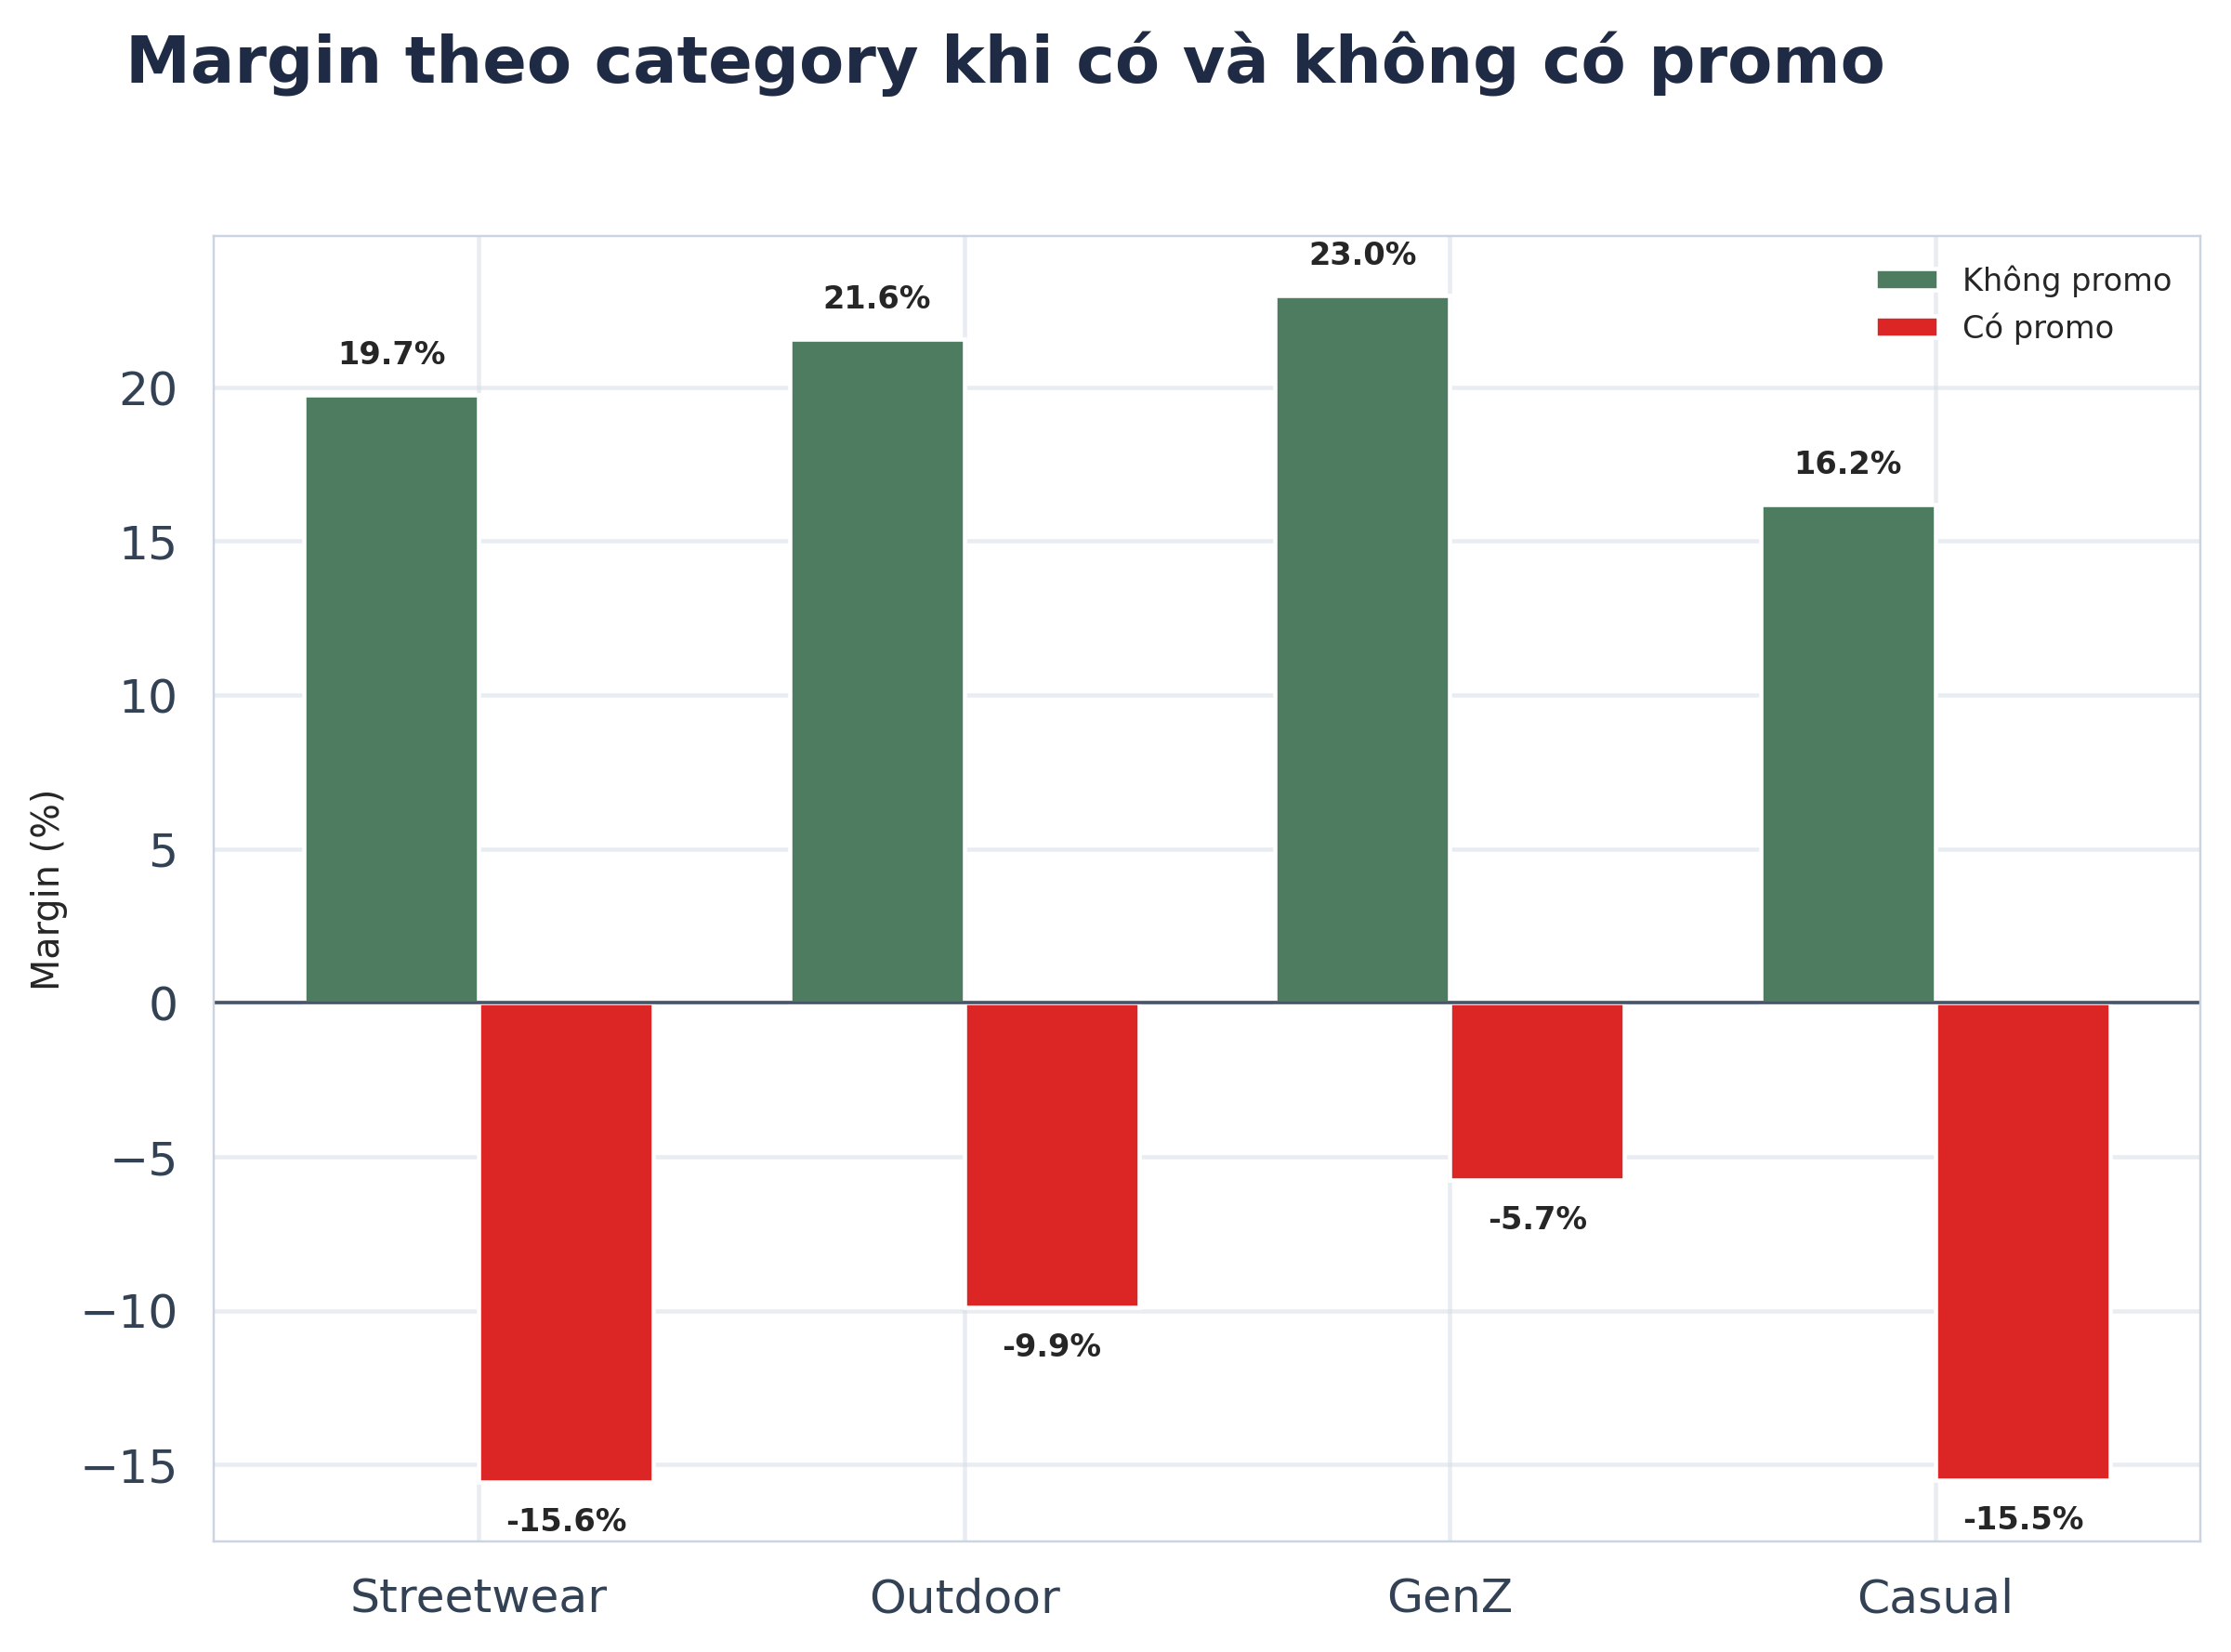

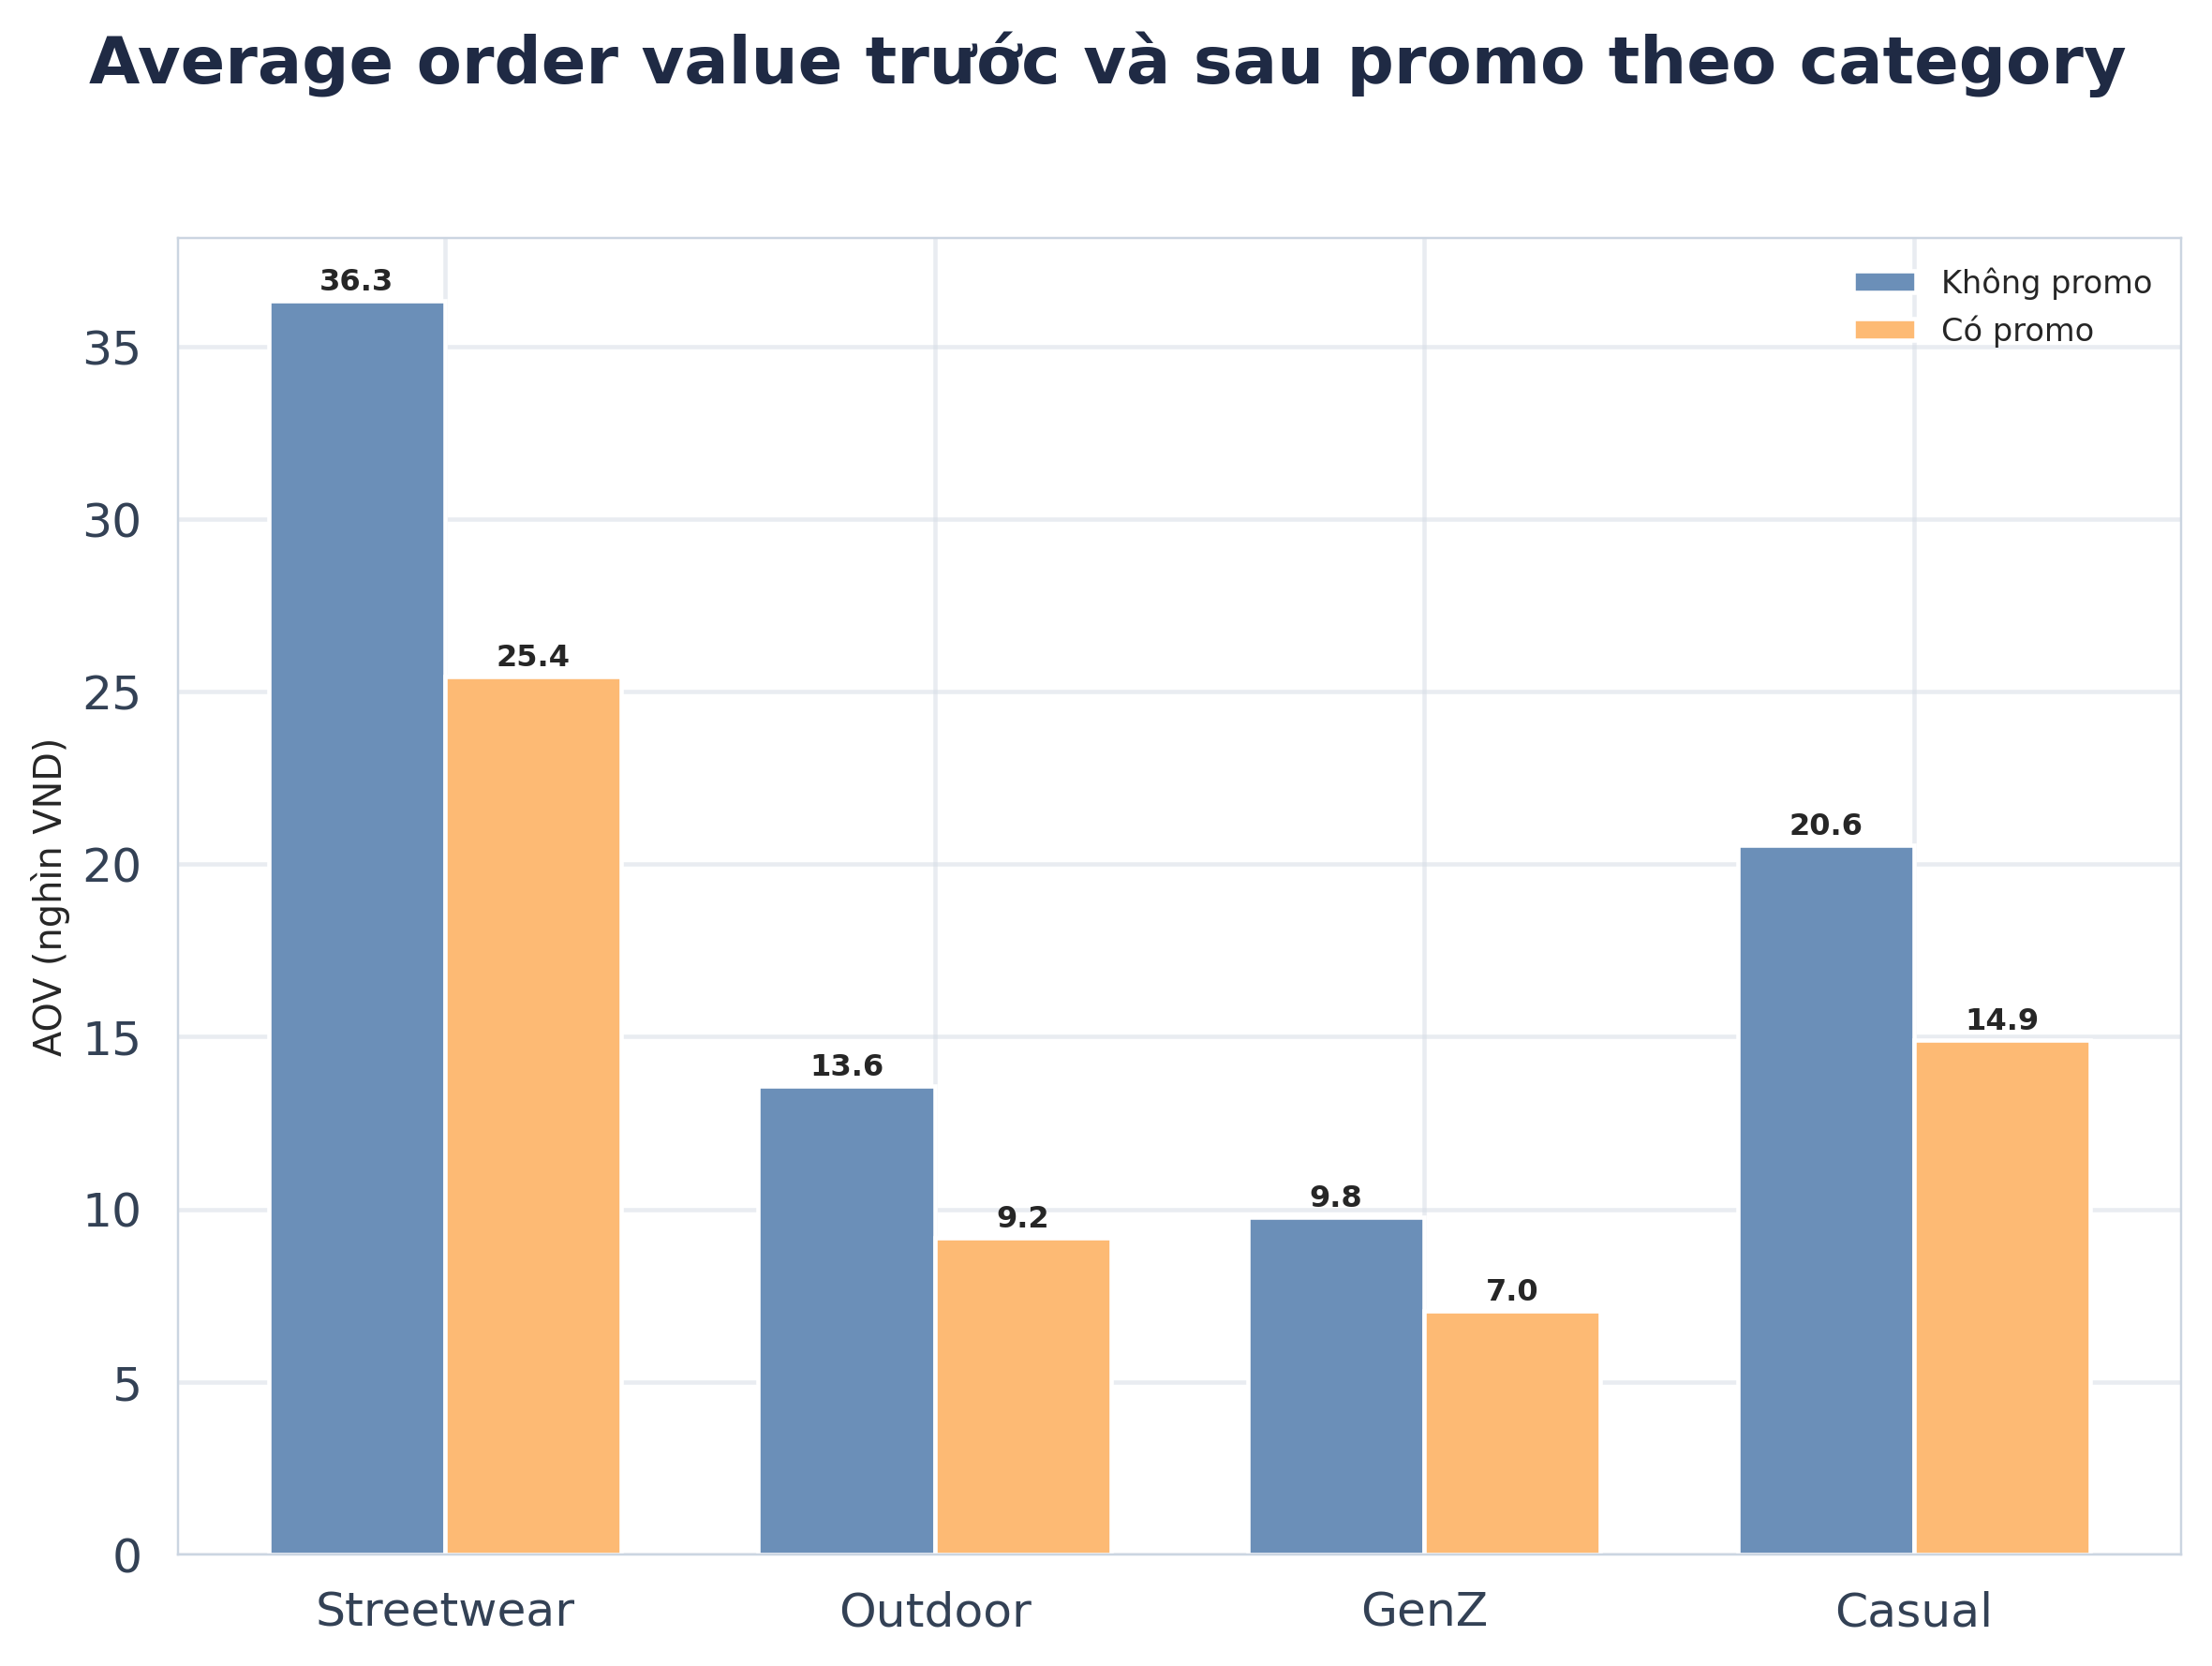

In [2]:
margin_pivot = category_margin.pivot(index='category', columns='promo_label', values='margin_pct').reindex(['Streetwear', 'Outdoor', 'GenZ', 'Casual'])
aov_pivot = category_aov.pivot(index='category', columns='promo_label', values='aov').reindex(['Streetwear', 'Outdoor', 'GenZ', 'Casual']) / 1_000
categories = margin_pivot.index.tolist()
xpos = np.arange(len(categories))
width = 0.36

fig, chart_axes, _ = create_story_card(top_shape=(1, 1), figsize=(10.8, 8.4))
ax = chart_axes[0]
apply_story_header(
    fig,
    ax,
    figure_title='Margin theo category khi có và không có promo',
    subtitle='',
    encoding_line='',
)
ax.bar(xpos - width / 2, margin_pivot['Không promo'], width=width, color='#4D7C61', label='Không promo')
ax.bar(xpos + width / 2, margin_pivot['Có promo'], width=width, color=RED, label='Có promo')
for offset, series in [(-width / 2, margin_pivot['Không promo']), (width / 2, margin_pivot['Có promo'])]:
    for idx, value in enumerate(series):
        ax.text(idx + offset, value + (0.8 if value >= 0 else -0.8), f'{value:.1f}%', ha='center', va='bottom' if value >= 0 else 'top', fontsize=11, fontweight='bold')
ax.axhline(0, color='#475569', linewidth=1.2)
ax.set_xticks(xpos)
ax.set_xticklabels(categories)
ax.set_ylabel('Margin (%)')
ax.legend(frameon=False, loc='upper right')
margin_path = out_dir / '02_margin_by_category.png'
save_story_card(fig, margin_path)
display(Image(filename=str(margin_path), width=1100))

fig, chart_axes, _ = create_story_card(top_shape=(1, 1), figsize=(10.8, 8.4))
ax = chart_axes[0]
apply_story_header(
    fig,
    ax,
    figure_title='Average order value trước và sau promo theo category',
    subtitle='',
    encoding_line='',
)
ax.bar(xpos - width / 2, aov_pivot['Không promo'], width=width, color='#6B8FB8', label='Không promo')
ax.bar(xpos + width / 2, aov_pivot['Có promo'], width=width, color='#FDBA74', label='Có promo')
for offset, series in [(-width / 2, aov_pivot['Không promo']), (width / 2, aov_pivot['Có promo'])]:
    for idx, value in enumerate(series):
        ax.text(idx + offset, value + 0.12, f'{value:.1f}', ha='center', va='bottom', fontsize=10.5, fontweight='bold')
ax.set_xticks(xpos)
ax.set_xticklabels(categories)
ax.set_ylabel('AOV (nghìn VND)')
ax.legend(frameon=False, loc='upper right')
aov_path = out_dir / '03_aov_before_after_promo.png'
save_story_card(fig, aov_path)
display(Image(filename=str(aov_path), width=1100))


### Ý tưởng phân tích
Tách hai câu hỏi khác nhau ở cùng cấp category: promo có phá unit economics hay không, và nếu có thì liệu nó có ít nhất nâng được giá trị đơn hàng để bù lại hay không.

### Phát hiện chính
Cả bốn category đều từ margin dương thành âm khi có promo. Đồng thời AOV không tăng đủ mạnh để bù phần gross profit mất đi, thậm chí ở nhiều category gần như đi ngang.

### Hàm ý kinh doanh
Promo đang hy sinh biên lợi nhuận mà không tạo ra basket chất lượng cao hơn. Nếu một chương trình vừa làm margin âm vừa không nâng được AOV, đó không phải growth engine mà chỉ là volume subsidy.

## Hình 3

Chart này đặt quality của từng nguồn traffic lên cùng một mặt phẳng và so sánh conversion trước/sau 2019.

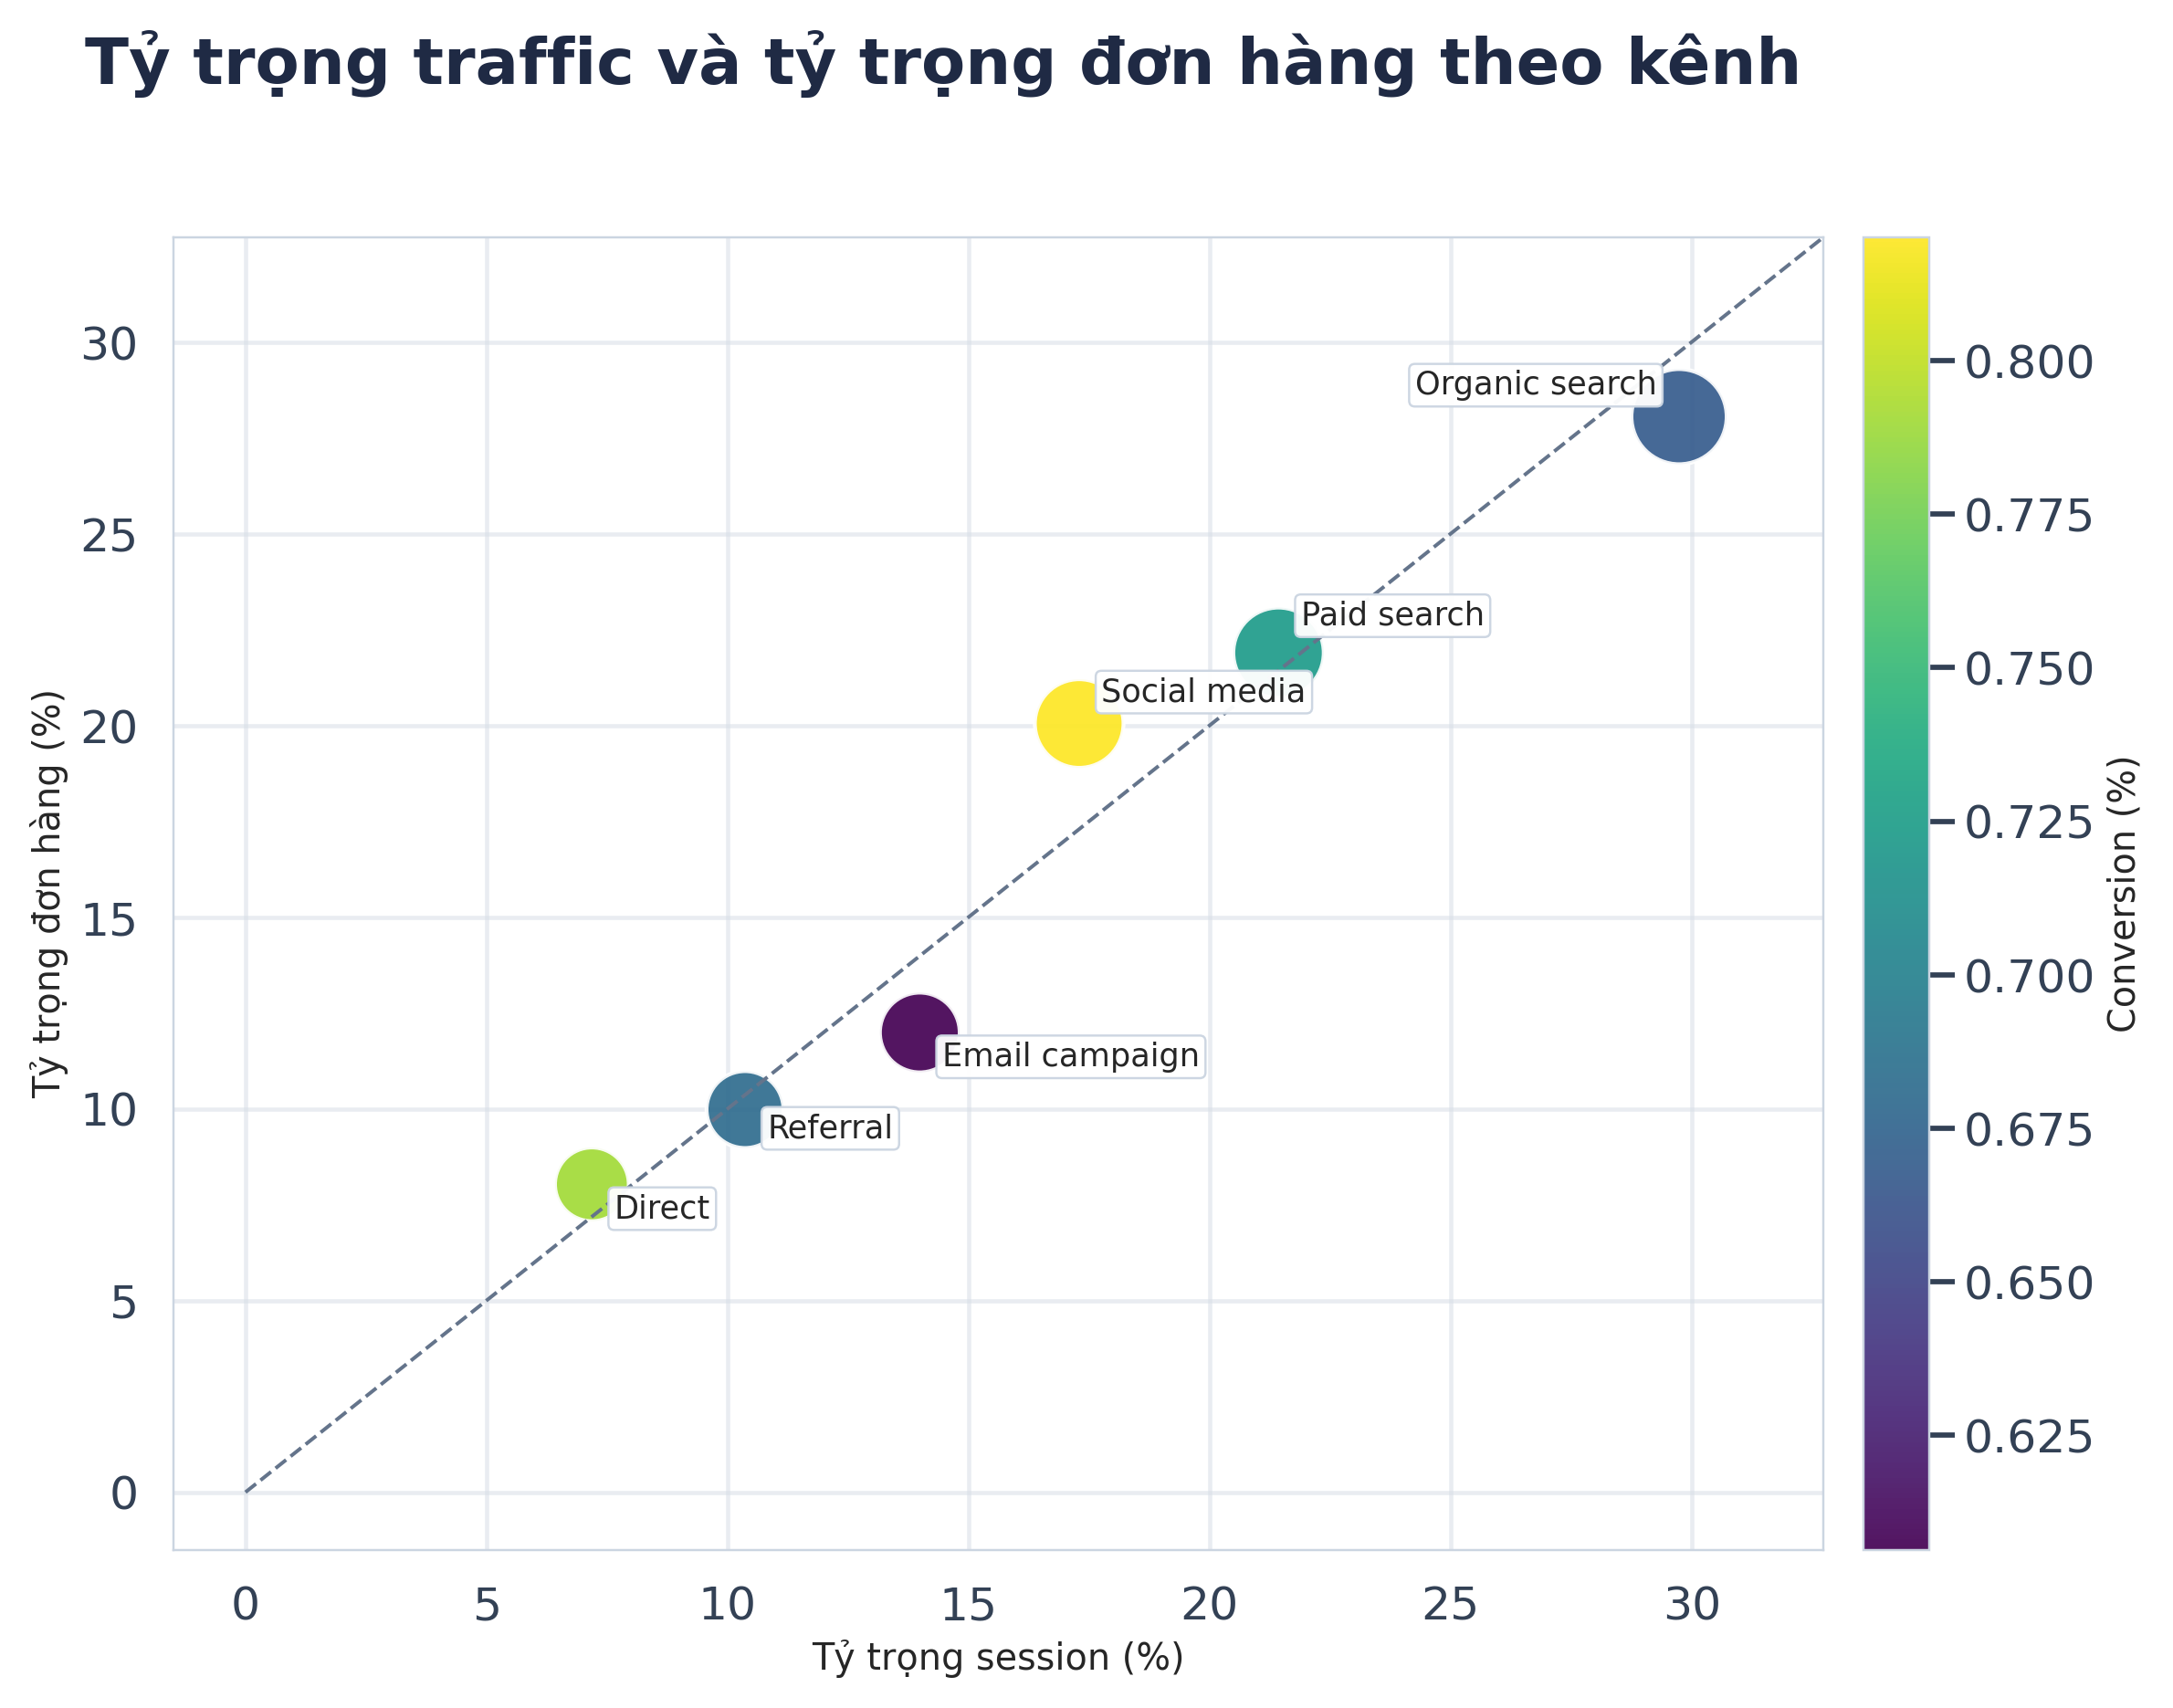

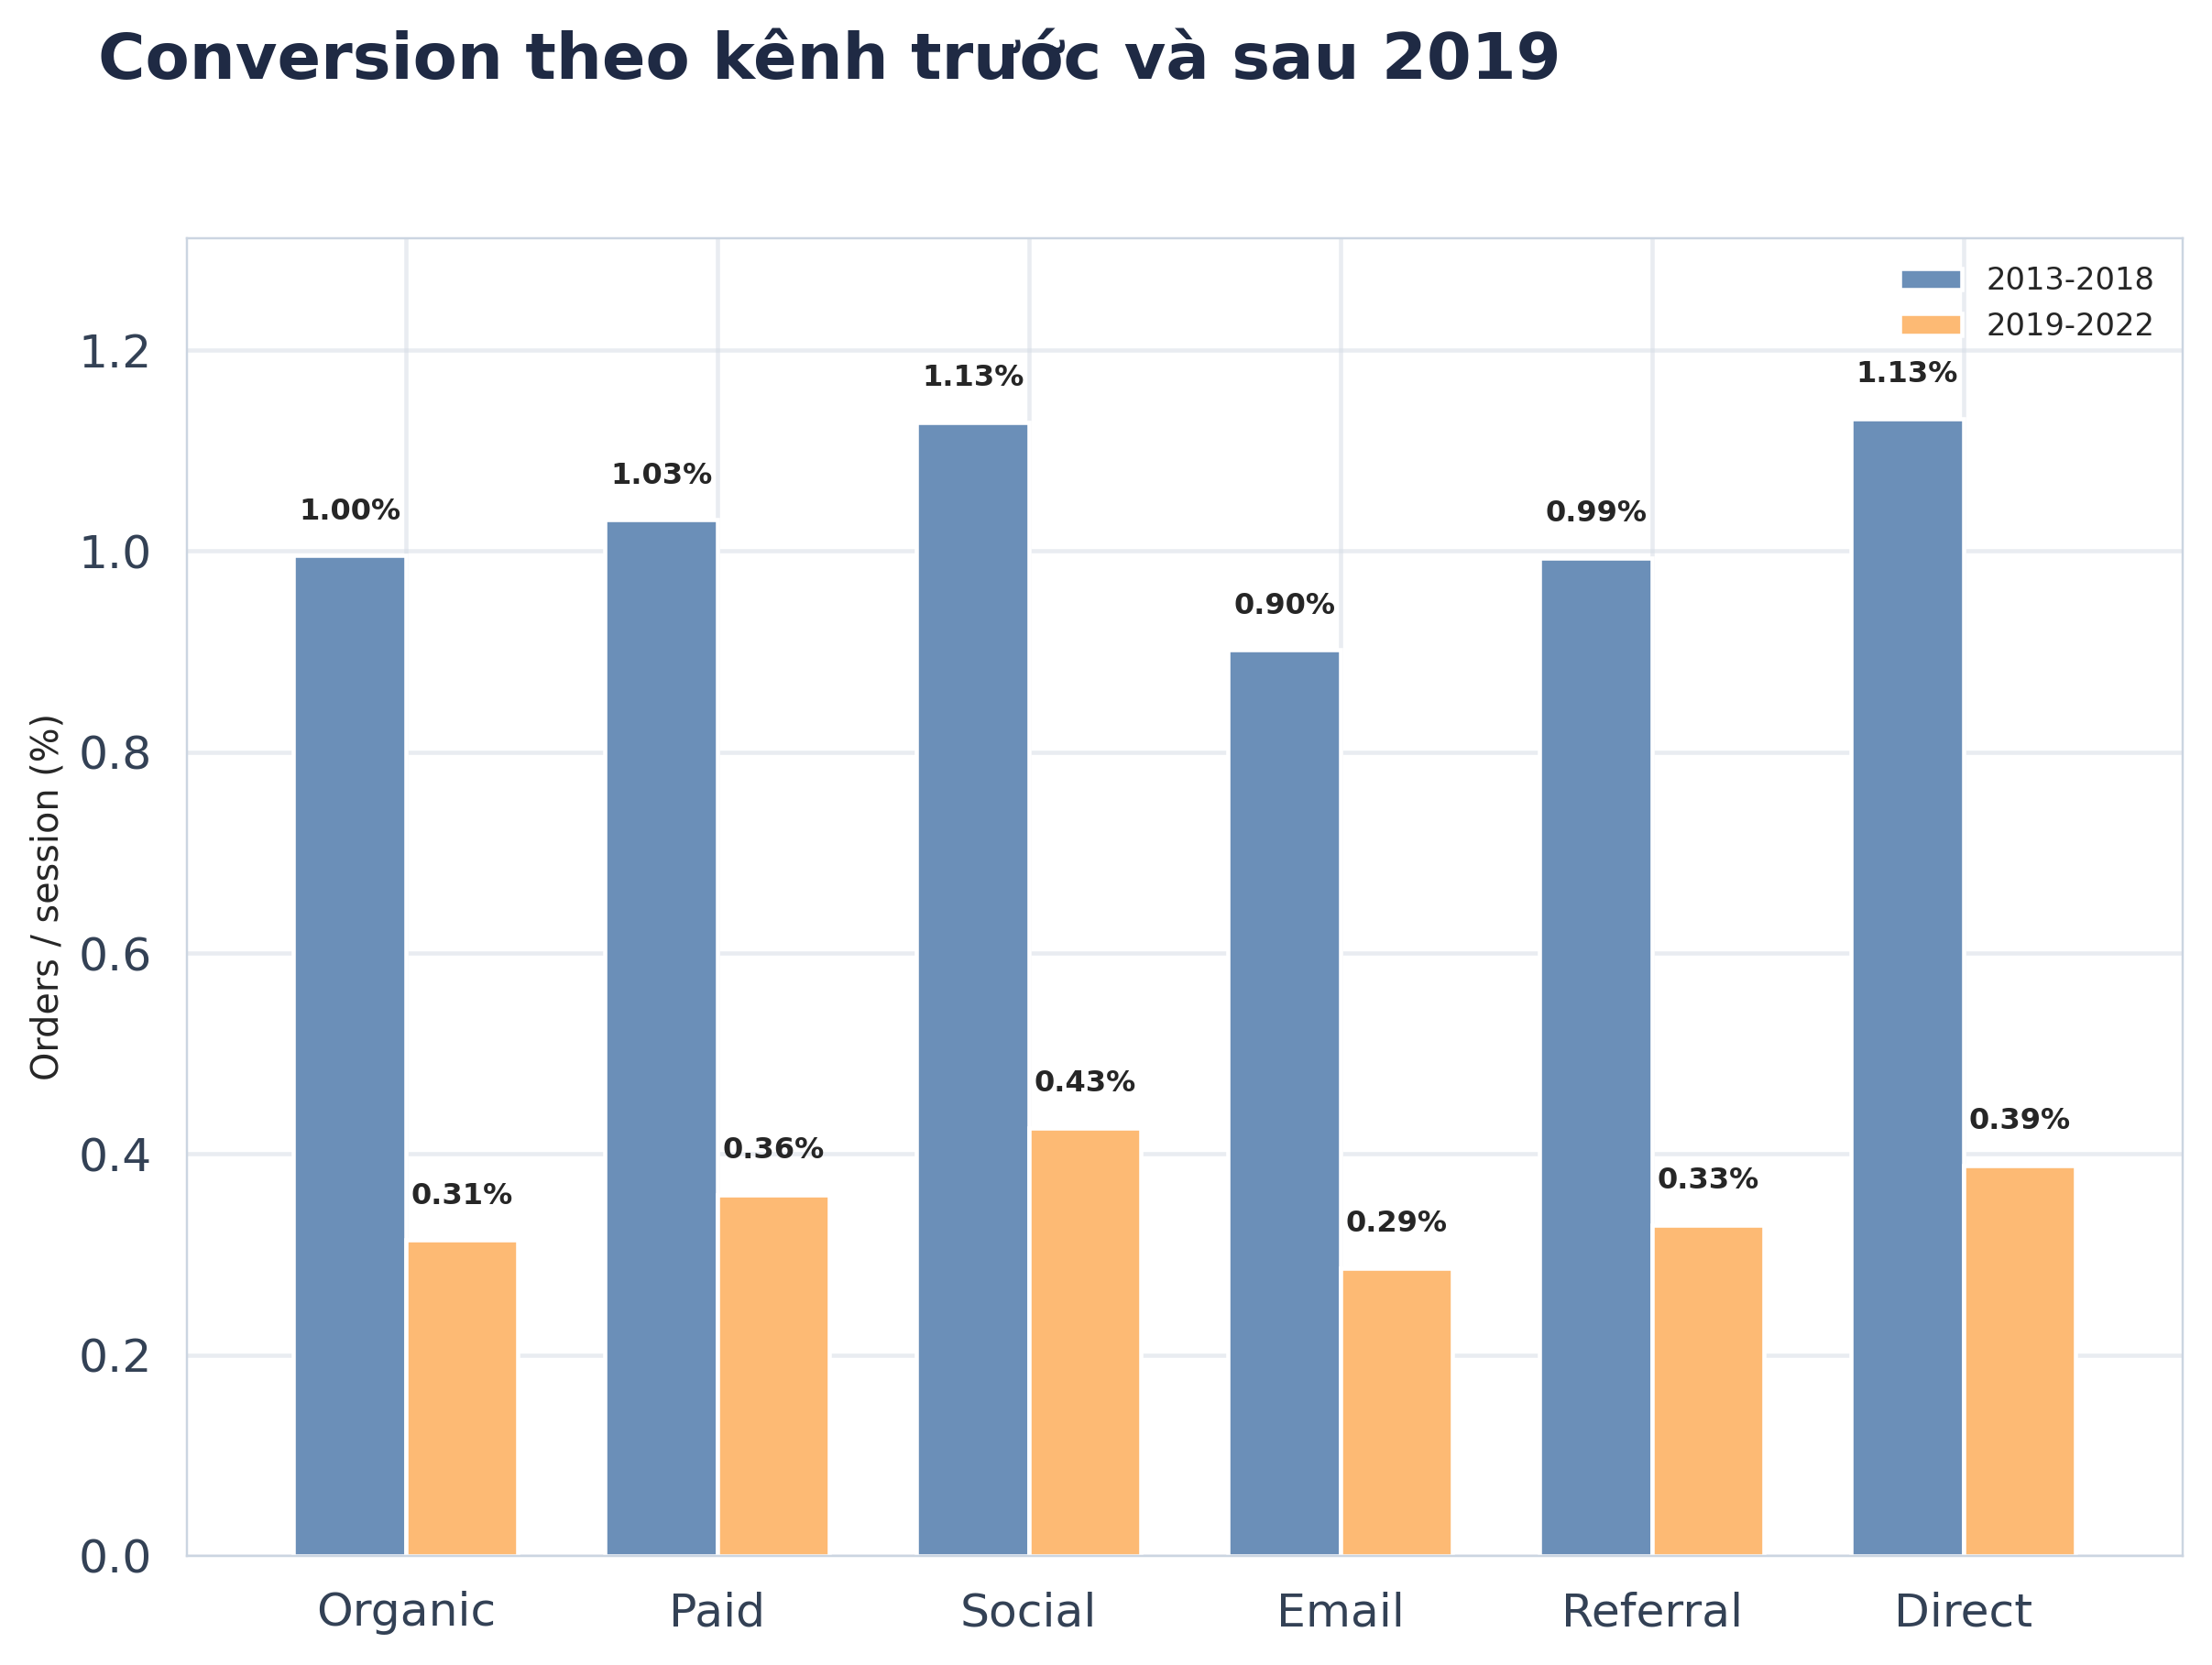

In [3]:
prepost = source_conv.pivot(index='source', columns='period', values='conversion_pct').reindex(
    ['organic_search', 'paid_search', 'social_media', 'email_campaign', 'referral', 'direct']
)
pretty_source = {
    'organic_search': 'Organic search',
    'paid_search': 'Paid search',
    'social_media': 'Social media',
    'email_campaign': 'Email campaign',
    'referral': 'Referral',
    'direct': 'Direct',
}
source_summary_plot = source_summary.copy()
source_summary_plot['pretty_source'] = source_summary_plot['source'].map(pretty_source)
prepost = prepost.rename(index=pretty_source)

fig, chart_axes, _ = create_story_card(top_shape=(1, 1), figsize=(11.0, 8.6))
ax = chart_axes[0]
apply_story_header(
    fig,
    ax,
    figure_title='Tỷ trọng traffic và tỷ trọng đơn hàng theo kênh',
    subtitle='',
    encoding_line='',
)
source_summary_plot['bubble_area'] = 160 + 190 * np.sqrt(source_summary_plot['revenue_share'])
scatter = ax.scatter(
    source_summary_plot['session_share'],
    source_summary_plot['order_share'],
    s=source_summary_plot['bubble_area'],
    c=source_summary_plot['conversion_pct'],
    cmap='viridis',
    alpha=0.92,
    edgecolor='white',
    linewidth=1.4,
)
max_axis = max(source_summary_plot['session_share'].max(), source_summary_plot['order_share'].max()) + 3
ax.plot([0, max_axis], [0, max_axis], linestyle='--', color='#64748B', linewidth=1.3)
label_styles = {
    'Organic search': {'offset': (-8, 8), 'ha': 'right'},
    'Paid search': {'offset': (8, 10), 'ha': 'left'},
    'Social media': {'offset': (8, 8), 'ha': 'left'},
    'Email campaign': {'offset': (8, -12), 'ha': 'left'},
    'Referral': {'offset': (8, -10), 'ha': 'left'},
    'Direct': {'offset': (8, -12), 'ha': 'left'},
}
for _, row in source_summary_plot.iterrows():
    style = label_styles[row['pretty_source']]
    dx, dy = style['offset']
    ax.annotate(
        row['pretty_source'],
        (row['session_share'], row['order_share']),
        xytext=(dx, dy),
        textcoords='offset points',
        ha=style['ha'],
        fontsize=11.5,
        bbox={'boxstyle': 'round,pad=0.18', 'fc': 'white', 'ec': '#CBD5E1', 'lw': 0.8, 'alpha': 0.96},
    )
ax.set_xlim(-1.5, max_axis)
ax.set_ylim(-1.5, max_axis)
ax.set_xlabel('Tỷ trọng session (%)')
ax.set_ylabel('Tỷ trọng đơn hàng (%)')
cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Conversion (%)')
share_path = out_dir / '04_channel_share_efficiency.png'
save_story_card(fig, share_path)
display(Image(filename=str(share_path), width=1100))

fig, chart_axes, _ = create_story_card(top_shape=(1, 1), figsize=(11.0, 8.6))
ax = chart_axes[0]
apply_story_header(
    fig,
    ax,
    figure_title='Conversion theo kênh trước và sau 2019',
    subtitle='',
    encoding_line='',
)
xpos = np.arange(len(prepost.index))
width = 0.36
ax.bar(xpos - width / 2, prepost['2013-2018'], width=width, color='#6B8FB8', label='2013-2018')
ax.bar(xpos + width / 2, prepost['2019-2022'], width=width, color='#FDBA74', label='2019-2022')
for offset, series in [(-width / 2, prepost['2013-2018']), (width / 2, prepost['2019-2022'])]:
    for idx, value in enumerate(series):
        ax.text(idx + offset, value + 0.03, f'{value:.2f}%', ha='center', va='bottom', fontsize=10.5, fontweight='bold')
ax.set_xticks(xpos)
ax.set_xticklabels(['Organic', 'Paid', 'Social', 'Email', 'Referral', 'Direct'])
ax.set_ylim(0, max(prepost.max()) + 0.18)
ax.set_ylabel('Orders / session (%)')
ax.legend(frameon=False, loc='upper right')
ax.margins(x=0.06)
conv_path = out_dir / '05_channel_conversion_before_after_2019.png'
save_story_card(fig, conv_path)
display(Image(filename=str(conv_path), width=1100))


### Ý tưởng phân tích
So sánh tỷ trọng traffic và tỷ trọng đơn hàng của từng kênh để đo chất lượng demand, sau đó đối chiếu conversion trước và sau 2019 để xem deterioration có mang tính hệ thống hay không.

### Phát hiện chính
- Organic search là kênh duy nhất tạo ra order share cao hơn session share một cách bền vững.
- Sau 2019, conversion giảm trên toàn bộ channel mix, không chỉ trên paid traffic.
- Kênh có chất lượng tốt nhất vẫn suy yếu, nên vấn đề nằm ở khả năng chuyển đổi của hệ thống hơn là ở một channel riêng lẻ.

### Hàm ý kinh doanh
Organic nên được dùng làm benchmark chất lượng cầu. Tối ưu ngân sách acquisition chỉ là bước sau; bước đầu là sửa những nguyên nhân khiến mọi kênh cùng mất conversion.


## Hình 5

Chart seasonality này kiểm tra xem promo có đang bù đắp tháng yếu hay chỉ phủ dày lên các tháng vốn không tạo incremental GP.

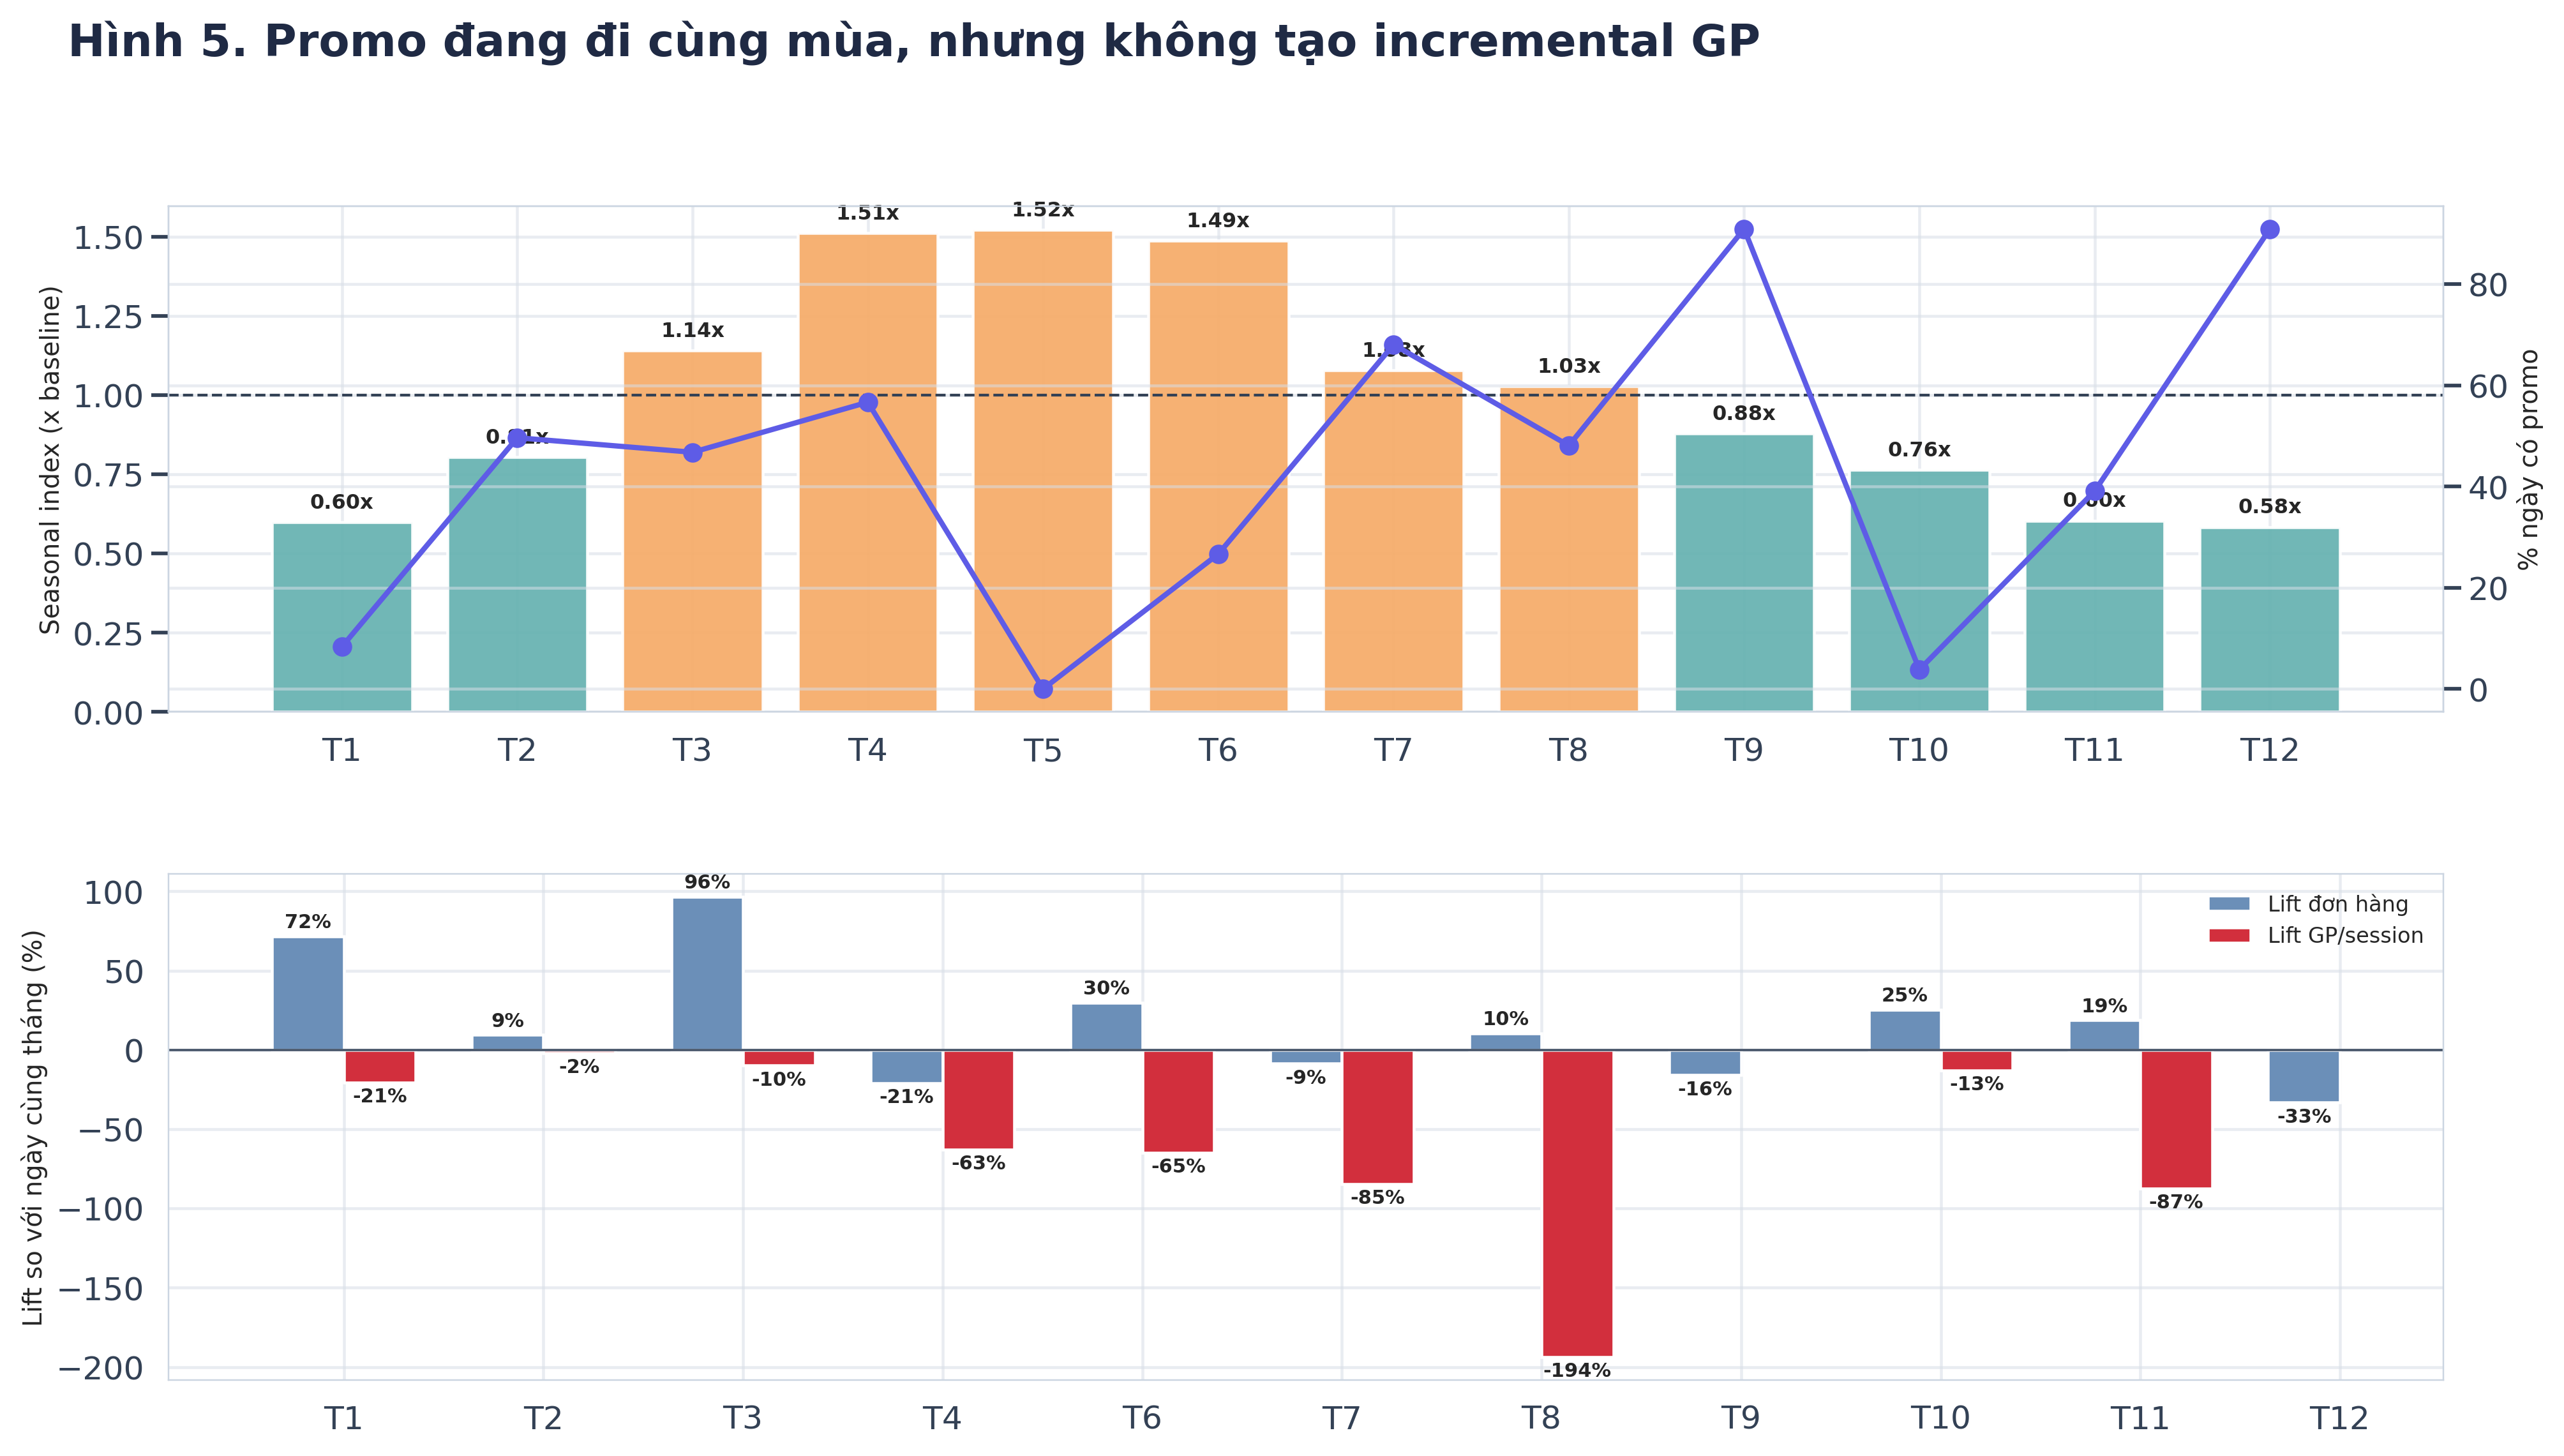

In [4]:
month_profile = month_profile.sort_values('month')
lift_frame = lift_frame.sort_values('month')
month_labels = [f'T{value}' for value in month_profile['month']]

fig, chart_axes, footer_axes = create_story_card(top_shape=(2, 1), figsize=(18, 11))
ax_top, ax_bottom = chart_axes
apply_story_header(
    fig,
    ax_top,
    figure_title='Hình 5. Promo đang đi cùng mùa, nhưng không tạo incremental GP',
    subtitle='Mùa mạnh tự nhiên nằm ở T3-T6, trong khi promo phủ rất dày ở T7-T12. Vấn đề là promo không kéo được chất lượng doanh thu ở các tháng yếu.',
    encoding_line='Panel trên dùng seasonal index của doanh thu ngày và % ngày có promo; panel dưới dùng lift của orders và GP/session so với ngày cùng tháng không promo',
)

bar_colors = ['#F6AD6B' if value >= 1 else '#69B3B2' for value in month_profile['seasonal_index']]
bars = ax_top.bar(month_labels, month_profile['seasonal_index'], color=bar_colors, alpha=0.95)
ax_top.axhline(1.0, color='#334155', linestyle='--', linewidth=1.4)
for bar, value in zip(bars, month_profile['seasonal_index']):
    ax_top.text(bar.get_x() + bar.get_width() / 2, value + 0.03, f'{value:.2f}x', ha='center', va='bottom', fontsize=10.5, fontweight='bold')
ax_top.set_ylabel('Seasonal index (x baseline)')
ax_top_twin = ax_top.twinx()
ax_top_twin.plot(month_labels, month_profile['promo_day_share'] * 100, color='#5E5CE6', marker='o', linewidth=2.7)
ax_top_twin.set_ylabel('% ngày có promo')

xpos = np.arange(len(lift_frame))
width = 0.36
month_ticks = [f'T{value}' for value in lift_frame['month']]
ax_bottom.bar(xpos - width / 2, lift_frame['orders_lift_pct'], width=width, color='#6B8FB8', label='Lift đơn hàng')
ax_bottom.bar(xpos + width / 2, lift_frame['gp_session_lift_pct'], width=width, color='#D22F3D', label='Lift GP/session')
for offset, series in [(-width / 2, lift_frame['orders_lift_pct']), (width / 2, lift_frame['gp_session_lift_pct'])]:
    for idx, value in enumerate(series):
        ax_bottom.text(idx + offset, value + (3 if value >= 0 else -3), f'{value:.0f}%', ha='center', va='bottom' if value >= 0 else 'top', fontsize=10, fontweight='bold')
ax_bottom.axhline(0, color='#475569', linewidth=1.2)
ax_bottom.set_xticks(xpos)
ax_bottom.set_xticklabels(month_ticks)
ax_bottom.set_ylabel('Lift so với ngày cùng tháng (%)')
ax_bottom.legend(frameon=False, loc='upper right')

fill_footer(
    footer_axes,
    [
        ('Ý tưởng phân tích', 'Ghép seasonality và promo coverage lên cùng một mặt phẳng để xem promo có đang bù cho tháng yếu hay chỉ đi theo mùa bán vốn có.'),
        ('Phát hiện chính', 'Promo phủ dày ở nhiều tháng có seasonal index dưới 1, nhưng GP/session lift hầu hết âm rất sâu dù order lift có thể dương.'),
        ('Hàm ý kinh doanh', 'Promo đang mua volume bằng cách phá lợi nhuận gộp. Không có bằng chứng về incremental GP ở các tháng yếu.'),
    ],
)

out_path = out_dir / '04_promo_no_incremental_gp.png'
save_story_card(fig, out_path)
display(Image(filename=str(out_path), width=1500))

### Ý tưởng phân tích
So sánh mùa tự nhiên với mức độ phủ promo và hai thước đo lift để kiểm tra giả thuyết: promotion có tạo thêm gross profit hay chỉ đi cùng mùa cao điểm.

### Phát hiện chính
- Promo phủ dày vào nhiều tháng vốn đã không yếu về seasonality.
- Lift đơn hàng có thể dương, nhưng lift GP/session nhiều tháng âm rất sâu.
- Điều đó nghĩa là promo đang đi cùng mùa và khuếch đại volume, nhưng không tạo incremental gross profit tương xứng.

### Hàm ý kinh doanh
Cần tách rõ hai mục tiêu: giữ volume và tạo giá trị. Nếu promotion không nâng GP/session, campaign đó nên bị triage lại hoặc cắt bỏ.


## Leakage từ hủy đơn và hoàn tiền

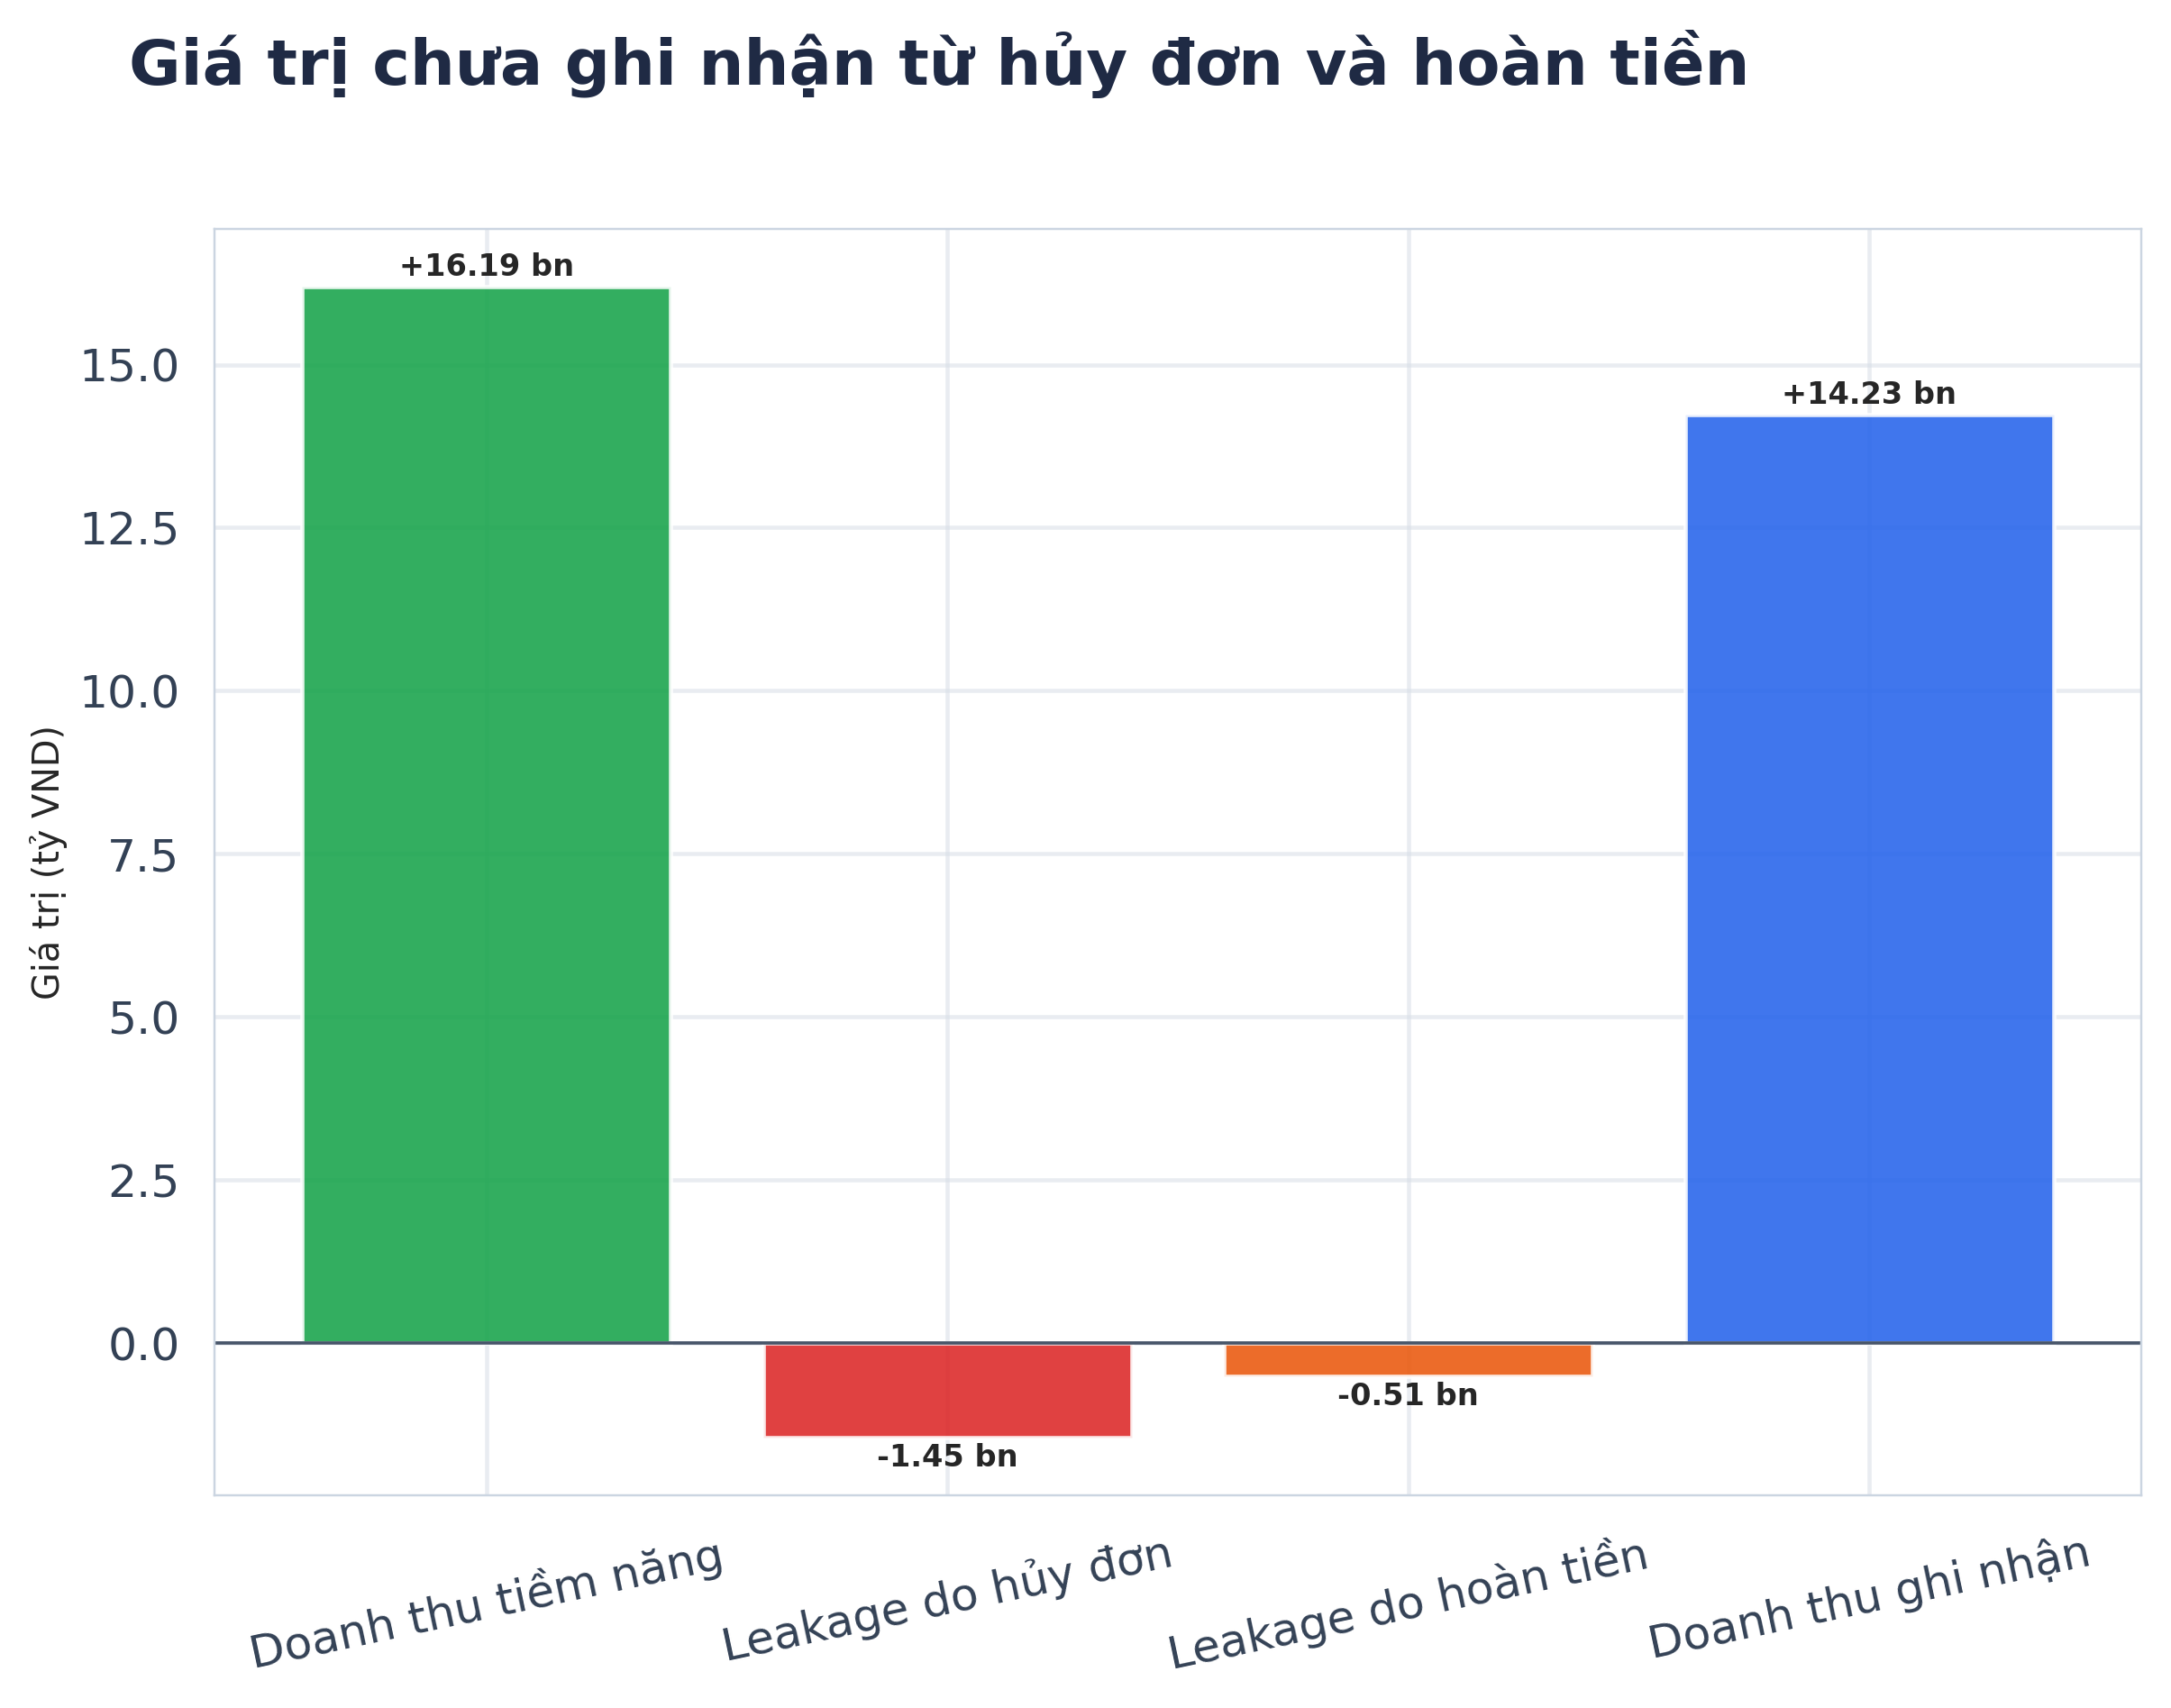

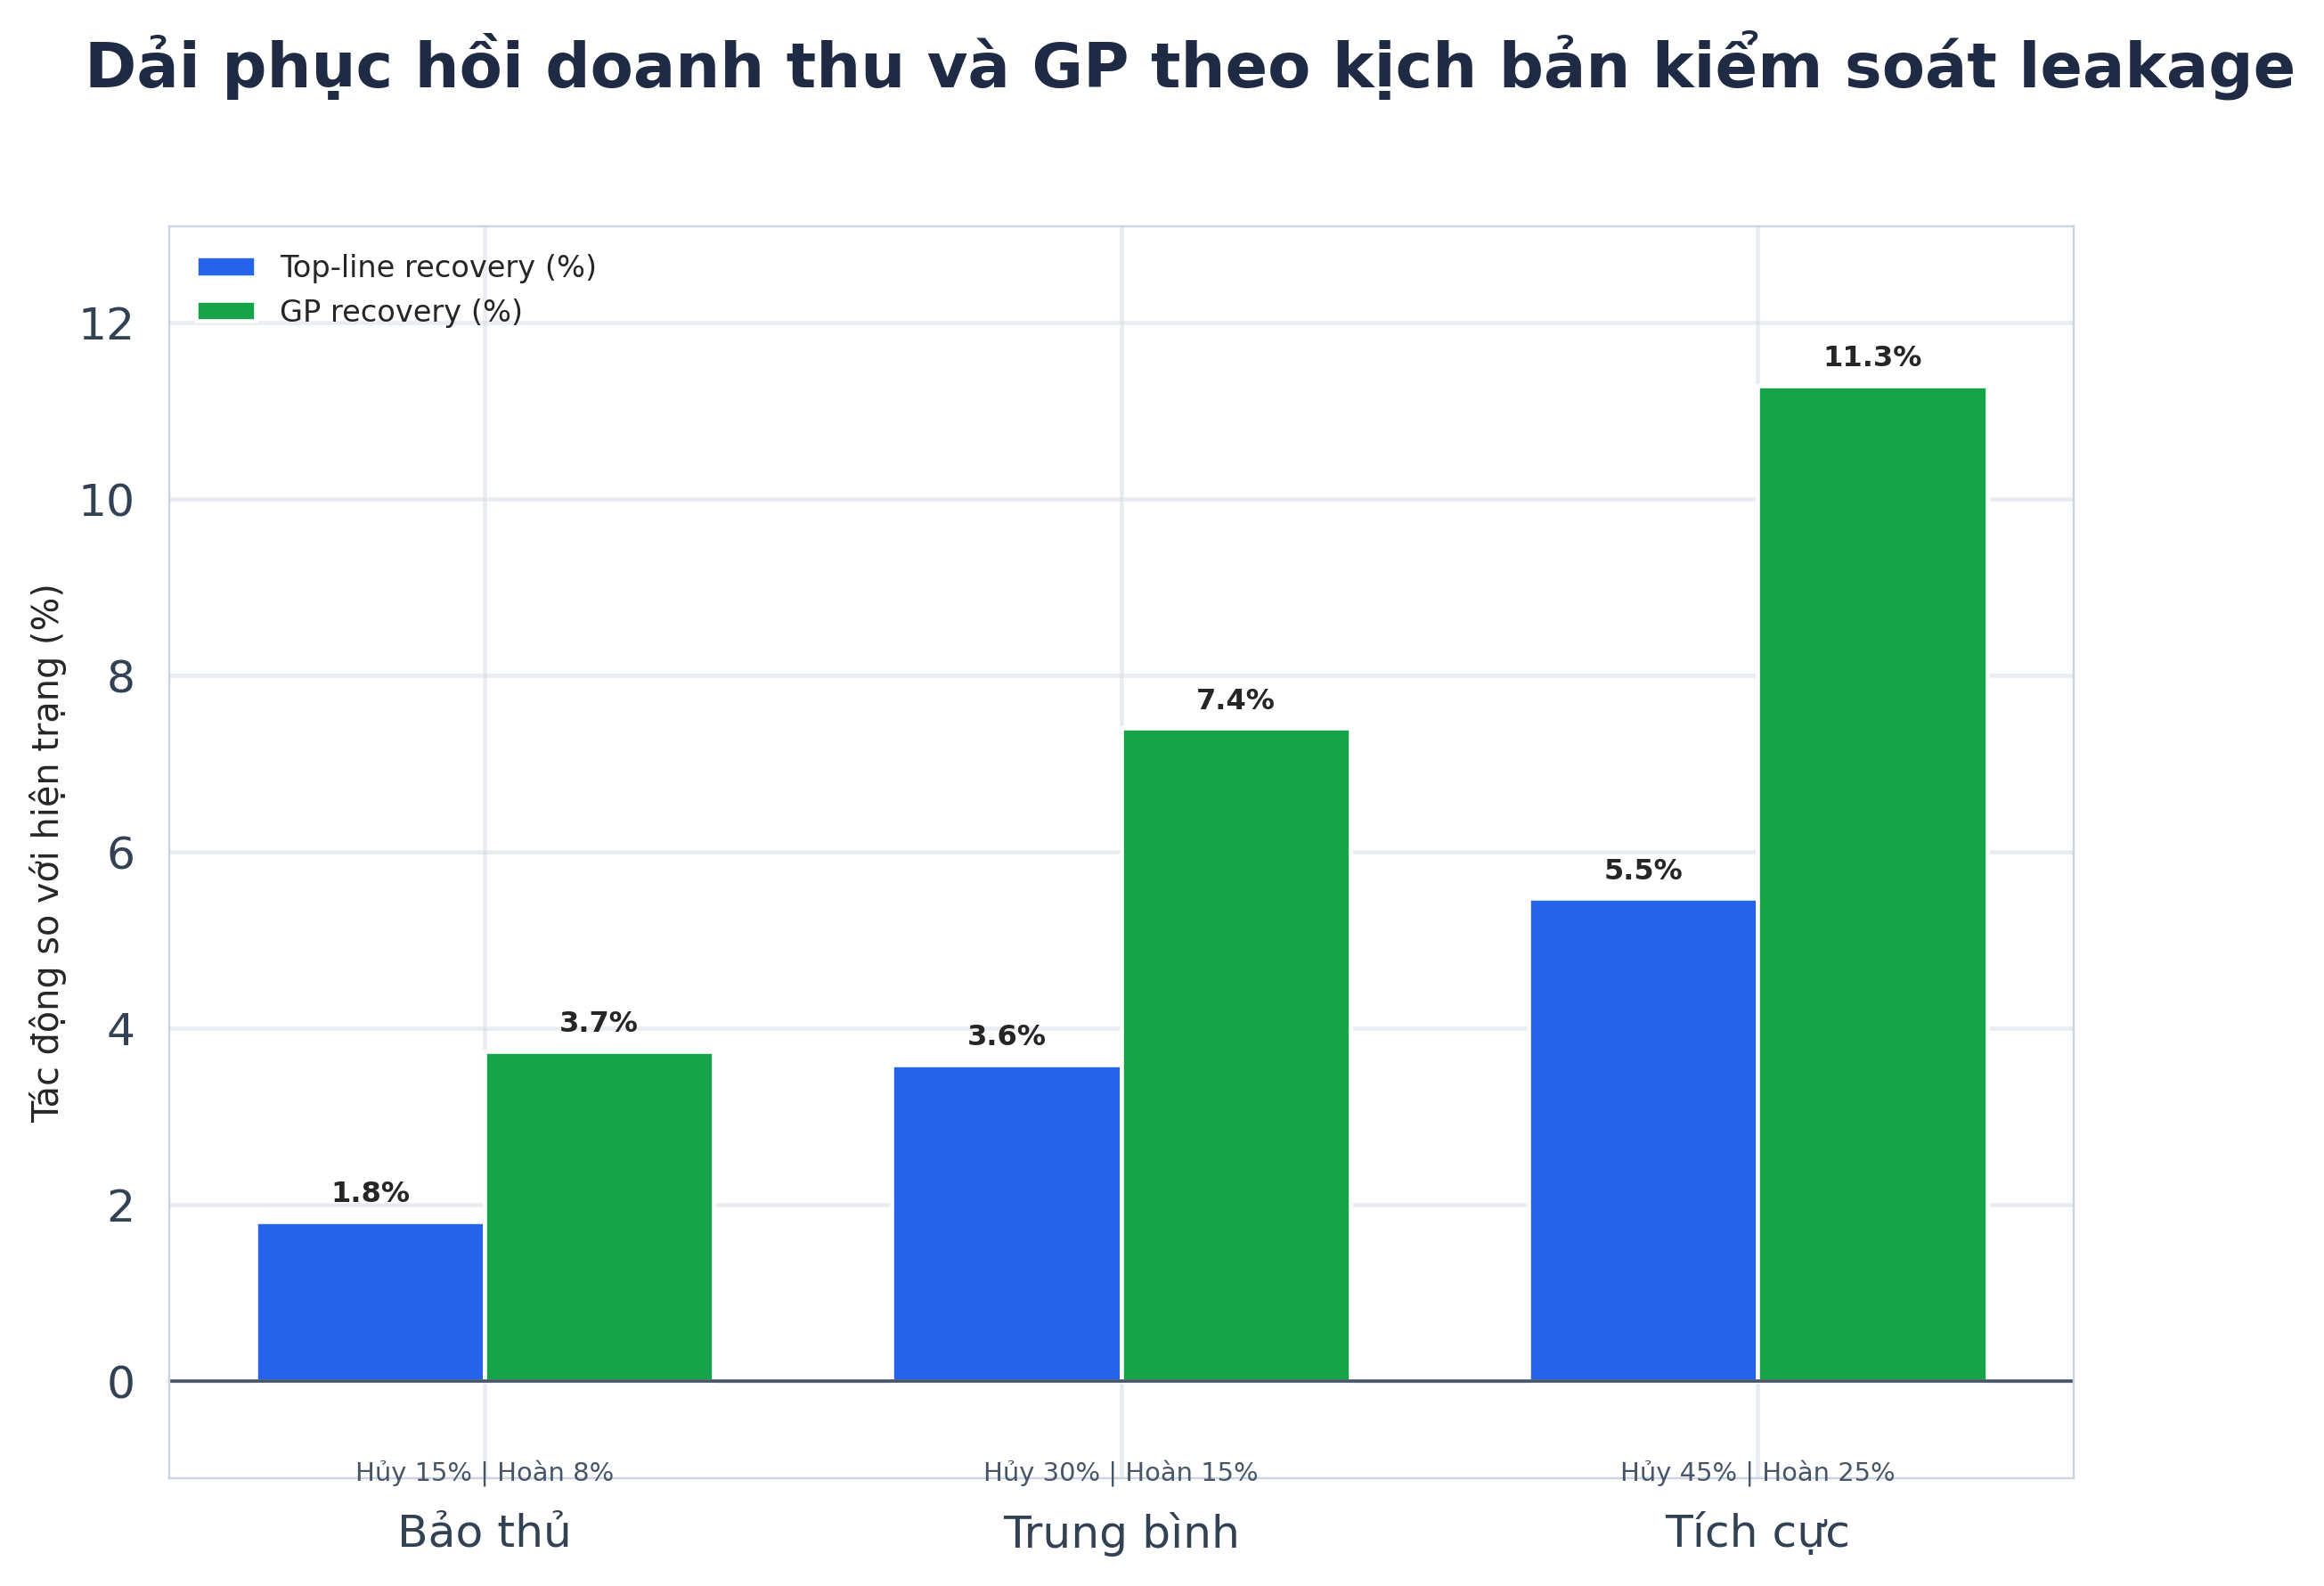

In [5]:
order_value = (
    item_frame.groupby(['order_id', 'order_date', 'order_status'], as_index=False)
    .agg(
        order_revenue=('net_revenue', 'sum'),
        order_gp=('gross_profit', 'sum'),
    )
)
order_value['order_month'] = pd.to_datetime(order_value['order_date']).dt.to_period('M').dt.to_timestamp()

realized_orders = order_value.loc[order_value['order_status'] != 'cancelled'].copy()
cancelled_orders = order_value.loc[order_value['order_status'] == 'cancelled'].copy()

refund_frame = returns.copy()
refund_frame['refund_month'] = pd.to_datetime(refund_frame['return_date']).dt.to_period('M').dt.to_timestamp()
monthly_refund = refund_frame.groupby('refund_month', as_index=False)['refund_amount'].sum()

monthly_realized = realized_orders.groupby('order_month', as_index=False)['order_revenue'].sum()
monthly_cancelled = cancelled_orders.groupby('order_month', as_index=False)['order_revenue'].sum()

leakage_monthly = (
    monthly_realized
    .merge(monthly_cancelled, on='order_month', how='left', suffixes=('_realized', '_cancelled'))
    .merge(monthly_refund, left_on='order_month', right_on='refund_month', how='left')
    .drop(columns=['refund_month'])
)
leakage_monthly = leakage_monthly.fillna(0.0)
leakage_monthly = leakage_monthly.rename(columns={'order_month': 'date'})
leakage_monthly['leakage_total'] = leakage_monthly['order_revenue_cancelled'] + leakage_monthly['refund_amount']

potential_revenue = leakage_monthly['order_revenue_realized'].sum() + leakage_monthly['leakage_total'].sum()
recognized_revenue = leakage_monthly['order_revenue_realized'].sum()
cancelled_leakage = leakage_monthly['order_revenue_cancelled'].sum()
refund_leakage = leakage_monthly['refund_amount'].sum()

base_margin = (
    item_frame.loc[(item_frame['promo_label'] == 'Không promo') & (item_frame['order_status'] != 'cancelled'), 'gross_profit'].sum()
    / item_frame.loc[(item_frame['promo_label'] == 'Không promo') & (item_frame['order_status'] != 'cancelled'), 'net_revenue'].sum()
)
base_margin = float(np.clip(base_margin, 0.08, 0.30))
current_gp = realized_orders['order_gp'].sum()

scenario = pd.DataFrame(
    {
        'scenario': ['Bảo thủ', 'Trung bình', 'Tích cực'],
        'cancel_recovery': [0.15, 0.30, 0.45],
        'refund_recovery': [0.08, 0.15, 0.25],
    }
)
scenario['recovered_revenue'] = (
    scenario['cancel_recovery'] * cancelled_leakage
    + scenario['refund_recovery'] * refund_leakage
)
scenario['recovered_gp'] = scenario['recovered_revenue'] * base_margin
scenario['revenue_impact_pct'] = scenario['recovered_revenue'] / recognized_revenue * 100
scenario['gp_impact_pct'] = scenario['recovered_gp'] / max(current_gp, 1.0) * 100

fig, chart_axes, _ = create_story_card(top_shape=(1, 1), figsize=(10.8, 8.4))
ax = chart_axes[0]
apply_story_header(
    fig,
    ax,
    figure_title='Giá trị chưa ghi nhận từ hủy đơn và hoàn tiền',
    subtitle='',
    encoding_line='',
)
waterfall_labels = ['Doanh thu tiềm năng', 'Leakage do hủy đơn', 'Leakage do hoàn tiền', 'Doanh thu ghi nhận']
waterfall_values = [potential_revenue / 1_000_000_000, -cancelled_leakage / 1_000_000_000, -refund_leakage / 1_000_000_000, recognized_revenue / 1_000_000_000]
colors = [GREEN, RED, ORANGE, BLUE]
x = np.arange(len(waterfall_labels))
ax.bar(x, waterfall_values, color=colors, alpha=0.88)
for idx, value in enumerate(waterfall_values):
    ax.text(idx, value + (0.08 if value >= 0 else -0.08), f'{value:+.2f} bn', ha='center', va='bottom' if value >= 0 else 'top', fontsize=11, fontweight='bold')
ax.axhline(0, color='#475569', linewidth=1.2)
ax.set_xticks(x)
ax.set_xticklabels(waterfall_labels, rotation=12)
ax.set_ylabel('Giá trị (tỷ VND)')
leak_path = out_dir / '14_leakage_unrealized_value.png'
save_story_card(fig, leak_path)
display(Image(filename=str(leak_path), width=1100))

fig, chart_axes, _ = create_story_card(top_shape=(1, 1), figsize=(10.8, 8.4))
ax = chart_axes[0]
apply_story_header(
    fig,
    ax,
    figure_title='Dải phục hồi doanh thu và GP theo kịch bản kiểm soát leakage',
    subtitle='',
    encoding_line='',
)
x2 = np.arange(len(scenario))
width = 0.36
ax.bar(x2 - width / 2, scenario['revenue_impact_pct'], width=width, color=BLUE, label='Top-line recovery (%)')
ax.bar(x2 + width / 2, scenario['gp_impact_pct'], width=width, color=GREEN, label='GP recovery (%)')
for idx, row in scenario.iterrows():
    ax.text(idx - width / 2, row['revenue_impact_pct'] + 0.15, f"{row['revenue_impact_pct']:.1f}%", ha='center', va='bottom', fontsize=10.5, fontweight='bold')
    ax.text(idx + width / 2, row['gp_impact_pct'] + 0.15, f"{row['gp_impact_pct']:.1f}%", ha='center', va='bottom', fontsize=10.5, fontweight='bold')
    ax.text(idx, -0.9, f"Hủy {int(row['cancel_recovery']*100)}% | Hoàn {int(row['refund_recovery']*100)}%", ha='center', va='top', fontsize=9.5, color='#475569')
ax.axhline(0, color='#475569', linewidth=1.2)
ax.set_xticks(x2)
ax.set_xticklabels(scenario['scenario'])
ax.set_ylim(-1.1, max(scenario['gp_impact_pct'].max(), scenario['revenue_impact_pct'].max()) + 1.8)
ax.set_ylabel('Tác động so với hiện trạng (%)')
ax.legend(frameon=False, loc='upper left')
recover_path = out_dir / '15_leakage_recovery_scenarios.png'
save_story_card(fig, recover_path)
display(Image(filename=str(recover_path), width=1100))


### Ý tưởng phân tích
Tách rõ doanh thu tiềm năng thành hai lớp leakage chính (hủy đơn và hoàn tiền) để tránh tranh luận cảm tính về việc “mất doanh thu ở đâu”.

### Phát hiện chính
Giá trị thất thoát do hủy đơn và hoàn tiền đang tạo một phần unrealized value rõ rệt. Khi mô phỏng các mức recovery khả thi (bảo thủ, trung bình, tích cực), cả top-line và GP đều cải thiện theo dải có thể lượng hóa.

### Hàm ý kinh doanh
Đây là đòn bẩy prescriptive ngắn hạn có thể triển khai ngay: ưu tiên giảm hủy đơn và giảm hoàn tiền ở nhóm lý do có thể kiểm soát, thay vì chỉ tăng cường độ promotion để bù doanh thu.


## Thử nghiệm. Ma trận ưu tiên tái thiết danh mục khuyến mãi


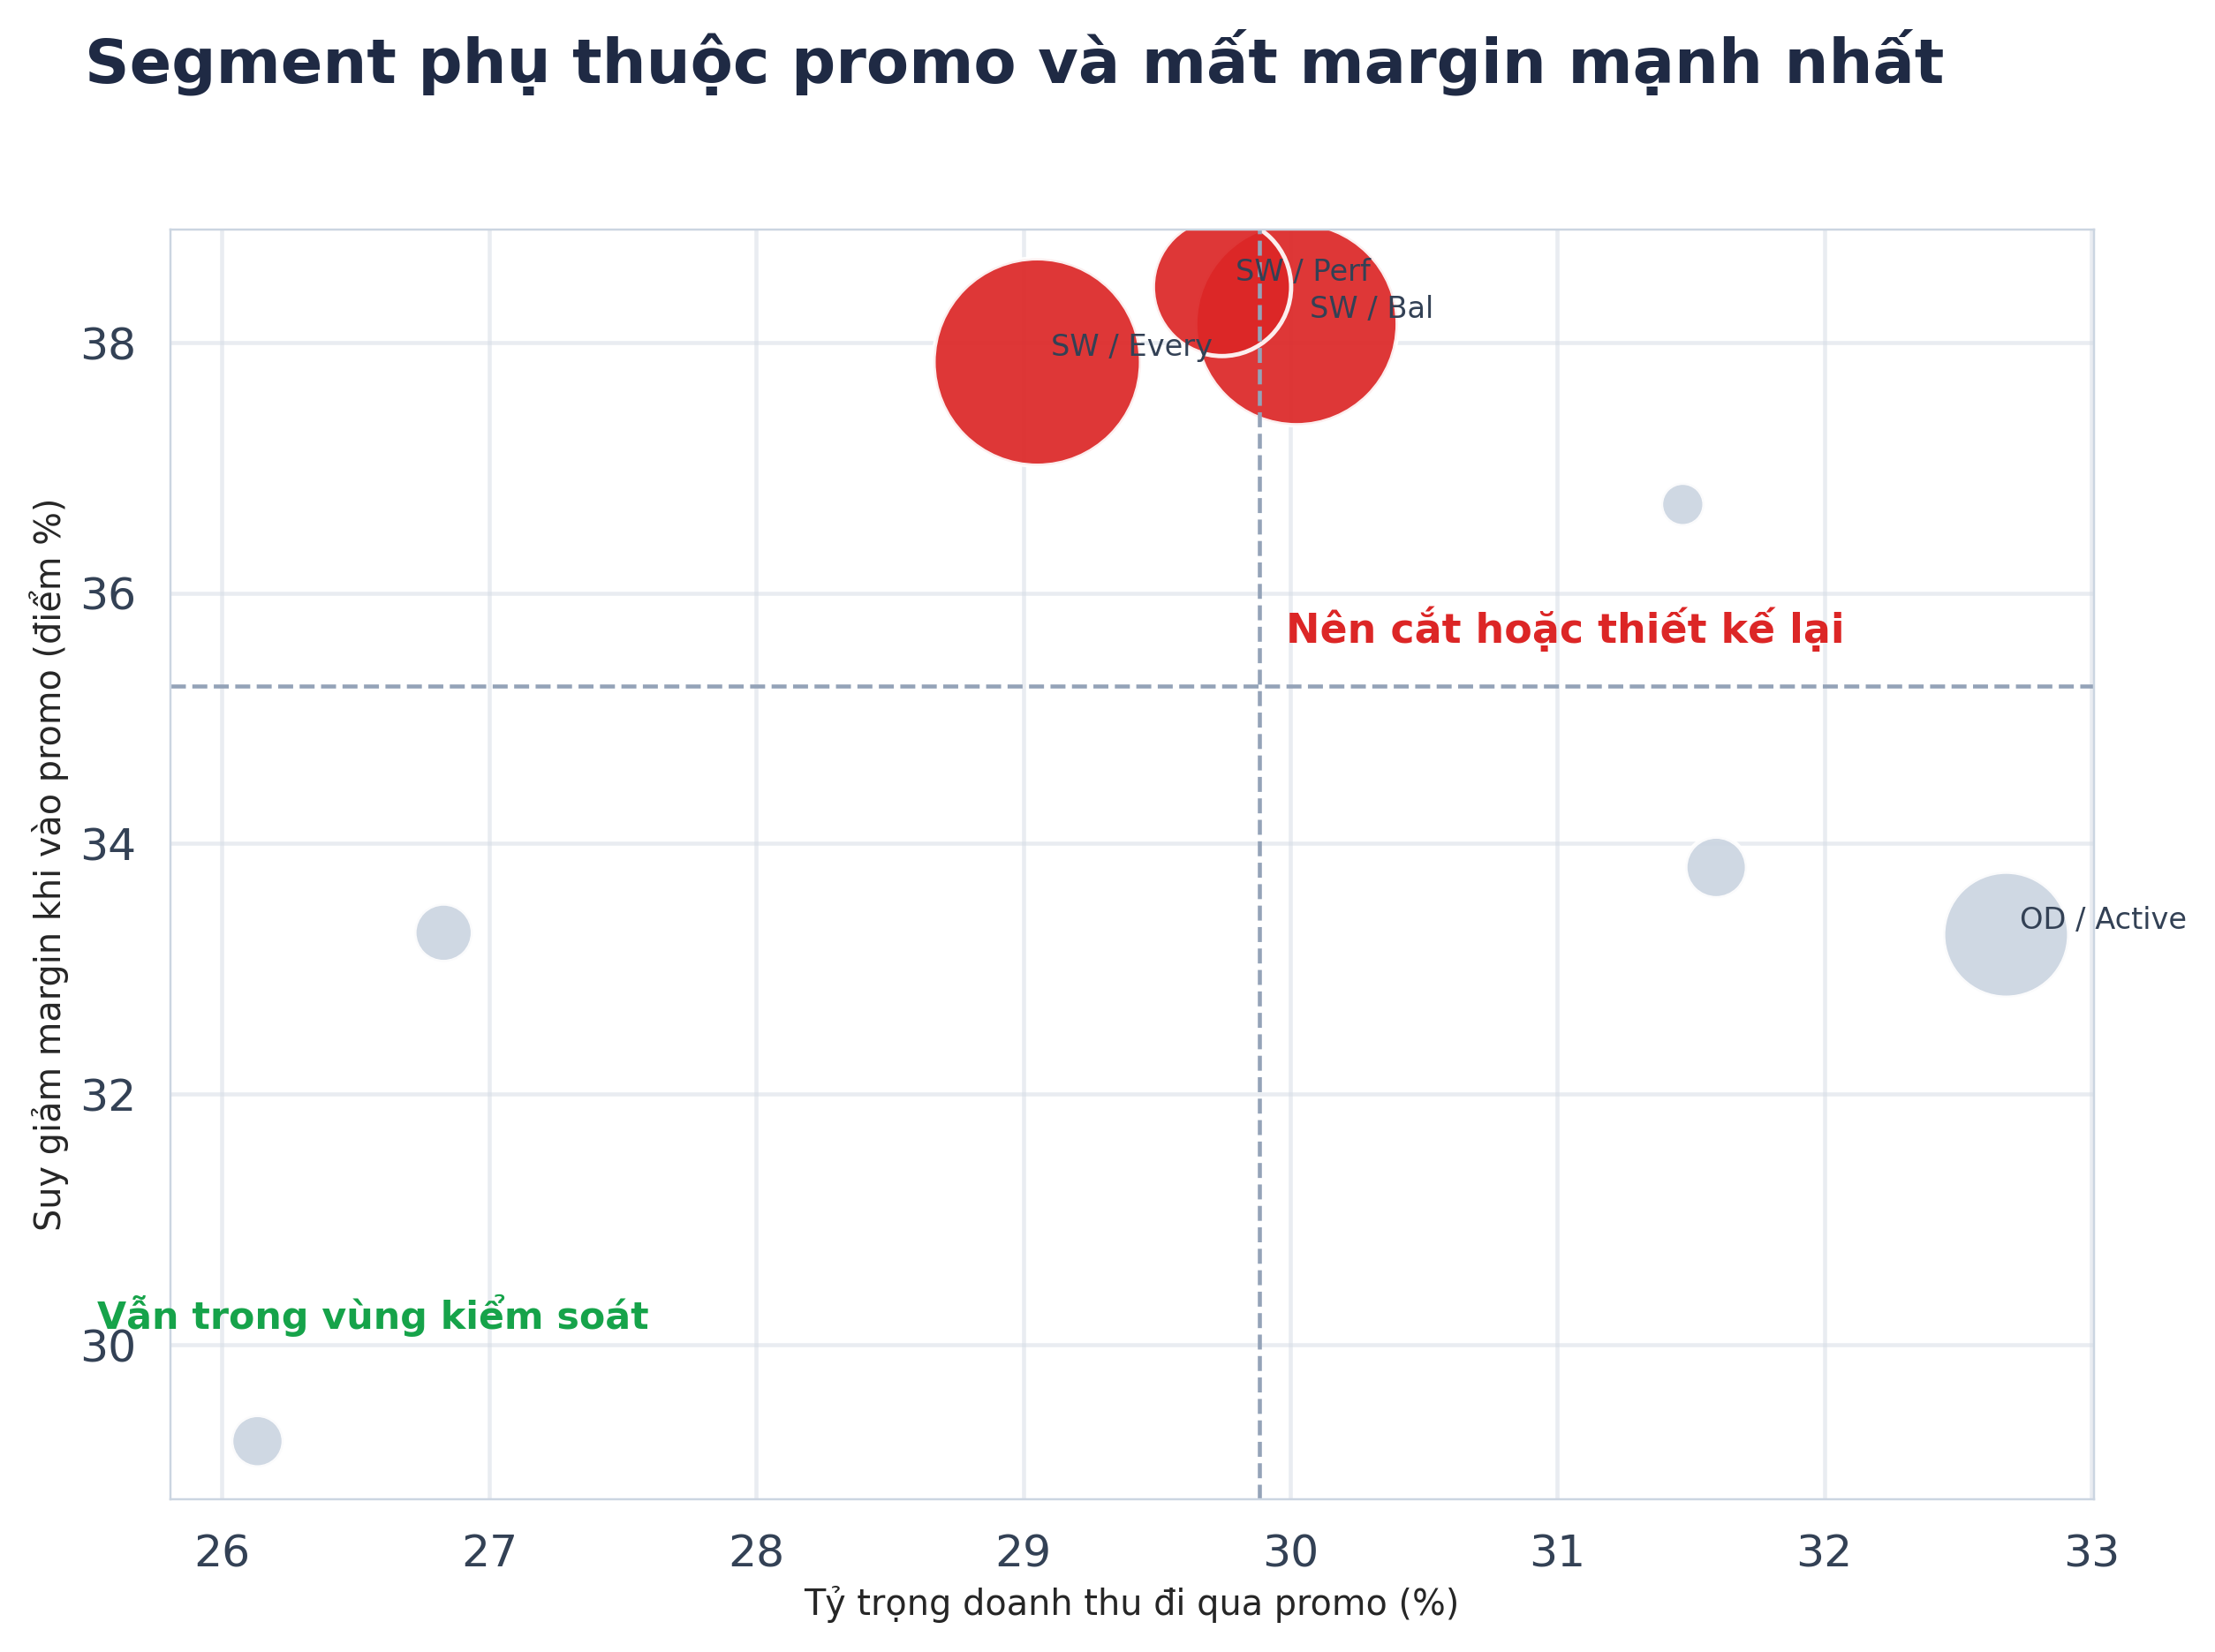

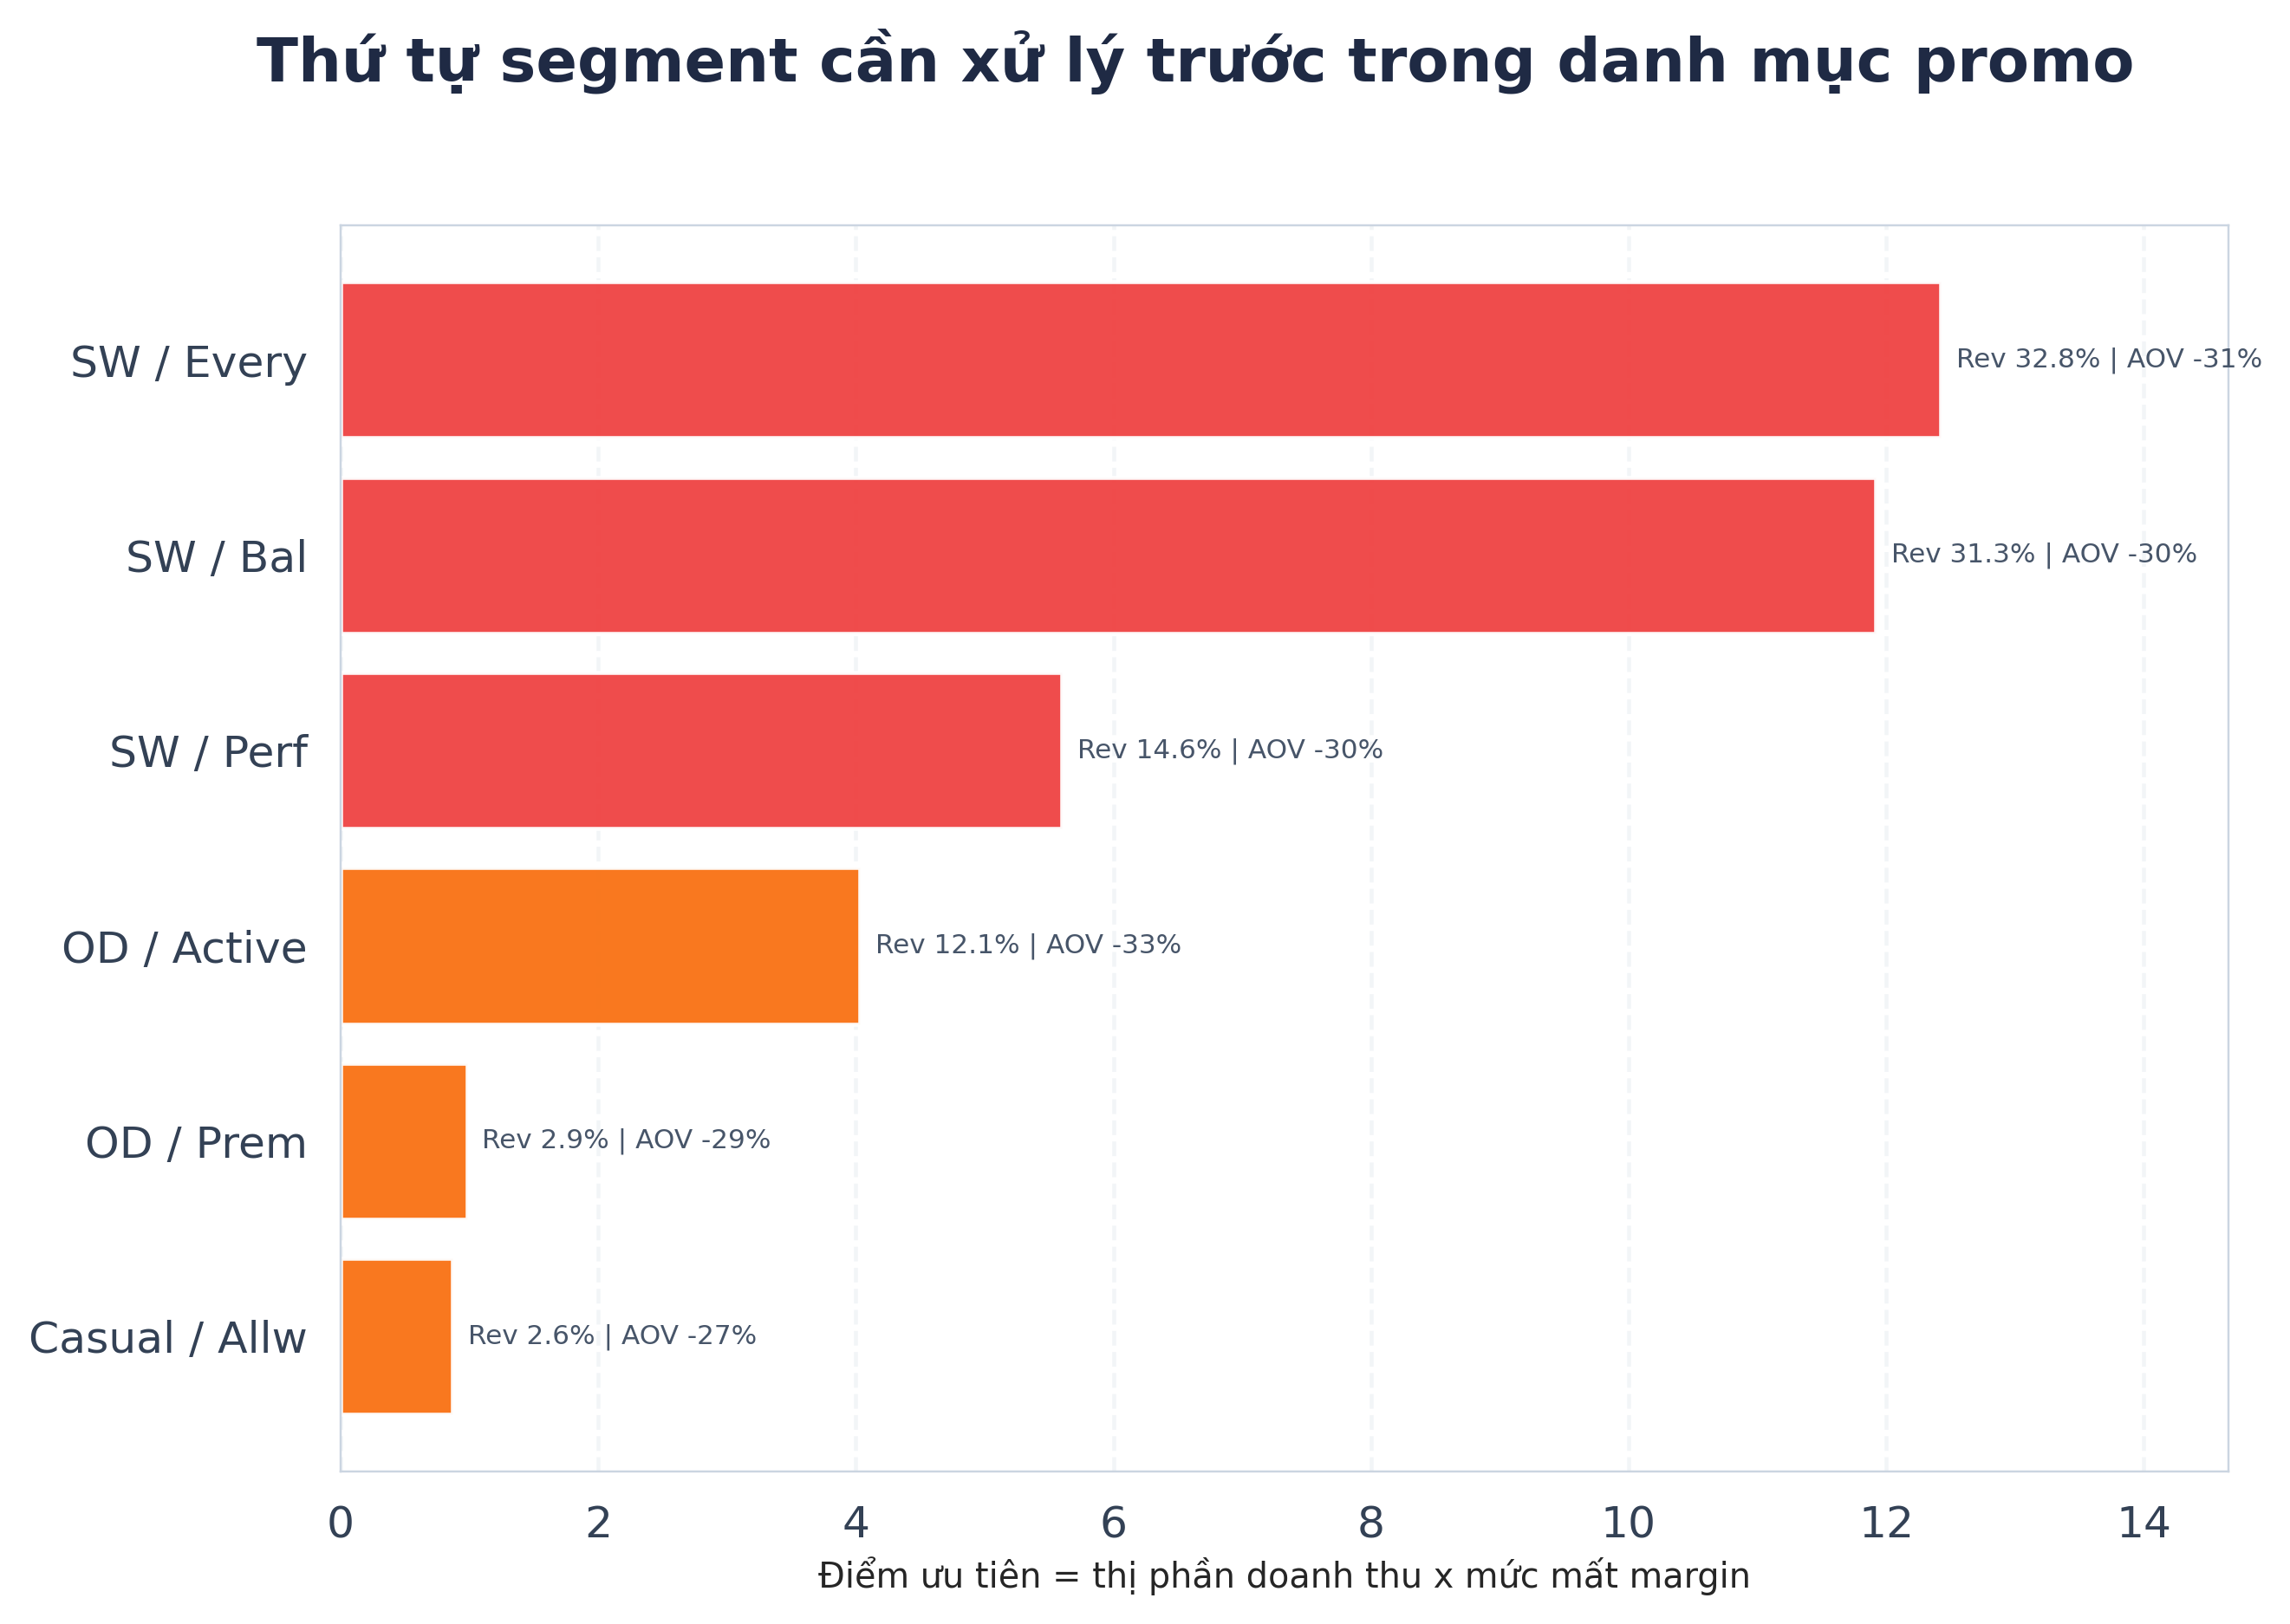

In [6]:
promo_items = items.merge(orders[['order_id', 'order_date']], on='order_id', how='left').copy()
promo_products = data['products'][['product_id', 'category', 'segment', 'cogs']].rename(columns={'cogs': 'unit_cogs'})
promo_items = promo_items.drop(columns=['category', 'unit_cogs'], errors='ignore').merge(promo_products, on='product_id', how='left')
promo_items['line_total'] = promo_items['quantity'] * promo_items['unit_price'] - promo_items['discount_amount'].fillna(0.0)
promo_items['line_cogs'] = promo_items['quantity'] * promo_items['unit_cogs'].fillna(0.0)
promo_items['gross_profit'] = promo_items['line_total'] - promo_items['line_cogs']
promo_items['group_label'] = promo_items['category'] + ' / ' + promo_items['segment'].fillna('Unknown')
promo_items['unit_net_price'] = promo_items['line_total'] / promo_items['quantity'].replace(0, np.nan)
promo_items['margin_pct'] = np.where(
    promo_items['line_total'] > 0,
    promo_items['gross_profit'] / promo_items['line_total'] * 100,
    np.nan,
)

promo_segment = (
    promo_items.groupby('group_label')
    .agg(
        revenue=('line_total', 'sum'),
        promo_revenue=('line_total', lambda s: s[promo_items.loc[s.index, 'promo_flag'].eq(1)].sum()),
        margin_no_promo=('margin_pct', lambda s: s[promo_items.loc[s.index, 'promo_flag'].eq(0)].mean()),
        margin_promo=('margin_pct', lambda s: s[promo_items.loc[s.index, 'promo_flag'].eq(1)].mean()),
        aov_no_promo=('unit_net_price', lambda s: s[promo_items.loc[s.index, 'promo_flag'].eq(0)].mean()),
        aov_promo=('unit_net_price', lambda s: s[promo_items.loc[s.index, 'promo_flag'].eq(1)].mean()),
    )
    .reset_index()
)
promo_segment['promo_revenue_share'] = promo_segment['promo_revenue'] / promo_segment['revenue'] * 100
promo_segment['promo_margin_damage_pp'] = promo_segment['margin_no_promo'] - promo_segment['margin_promo']
promo_segment['aov_delta_pct'] = (promo_segment['aov_promo'] / promo_segment['aov_no_promo'] - 1) * 100
promo_segment['revenue_share_pct'] = promo_segment['revenue'] / promo_segment['revenue'].sum() * 100
promo_segment = promo_segment.loc[promo_segment['revenue_share_pct'] >= 1.0].copy()
promo_segment['risk_score'] = promo_segment['revenue_share_pct'] * promo_segment['promo_margin_damage_pp'] / 100
promo_segment['short_label'] = (
    promo_segment['group_label']
    .str.replace('Streetwear', 'SW', regex=False)
    .str.replace('Outdoor', 'OD', regex=False)
    .str.replace('Performance', 'Perf', regex=False)
    .str.replace('Premium', 'Prem', regex=False)
    .str.replace('Activewear', 'Active', regex=False)
    .str.replace('Balanced', 'Bal', regex=False)
    .str.replace('Everyday', 'Every', regex=False)
    .str.replace('All-weather', 'Allw', regex=False)
    .str.replace('Standard', 'Std', regex=False)
    .str.replace('Trendy', 'Trend', regex=False)
)
promo_segment = promo_segment.sort_values('risk_score', ascending=False)

top_segments = set(promo_segment.head(3)['short_label'])
promo_segment['plot_color'] = np.where(promo_segment['short_label'].isin(top_segments), '#DC2626', '#CBD5E1')

fig, chart_axes, _ = create_story_card(top_shape=(1, 1), figsize=(11.0, 8.6))
ax = chart_axes[0]
apply_story_header(
    fig,
    ax,
    figure_title='Segment phụ thuộc promo và mất margin mạnh nhất',
    subtitle='',
    encoding_line='',
)
x_cut = promo_segment['promo_revenue_share'].median()
y_cut = promo_segment['promo_margin_damage_pp'].median()
ax.scatter(
    promo_segment['promo_revenue_share'],
    promo_segment['promo_margin_damage_pp'],
    s=promo_segment['revenue_share_pct'] * 180,
    c=promo_segment['plot_color'],
    alpha=0.92,
    edgecolor='white',
    linewidth=1.6,
)
ax.axvline(x_cut, color='#94A3B8', linestyle='--', linewidth=1.5)
ax.axhline(y_cut, color='#94A3B8', linestyle='--', linewidth=1.5)
ax.text(x_cut + 0.10, y_cut + 0.35, 'Nên cắt hoặc thiết kế lại', color='#DC2626', fontsize=15, fontweight='bold')
ax.text(promo_segment['promo_revenue_share'].min() - 0.6, promo_segment['promo_margin_damage_pp'].min() + 0.9, 'Vẫn trong vùng kiểm soát', color='#16A34A', fontsize=14, fontweight='bold')
for _, row in promo_segment.head(4).iterrows():
    ax.text(row['promo_revenue_share'] + 0.05, row['promo_margin_damage_pp'] + 0.05, row['short_label'], fontsize=11, color='#334155')
ax.set_xlabel('Tỷ trọng doanh thu đi qua promo (%)')
ax.set_ylabel('Suy giảm margin khi vào promo (điểm %)')
scatter_path = out_dir / 'exp_promo_dependency_margin.png'
save_story_card(fig, scatter_path)
display(Image(filename=str(scatter_path), width=1100))

rank = promo_segment.head(6).sort_values('risk_score')
colors = np.where(rank['risk_score'] >= rank['risk_score'].median(), '#EF4444', '#F97316')
fig, chart_axes, _ = create_story_card(top_shape=(1, 1), figsize=(11.0, 8.6))
ax = chart_axes[0]
apply_story_header(
    fig,
    ax,
    figure_title='Thứ tự segment cần xử lý trước trong danh mục promo',
    subtitle='',
    encoding_line='',
)
ax.barh(rank['short_label'], rank['risk_score'], color=colors, alpha=0.96)
for y, (_, row) in enumerate(rank.iterrows()):
    ax.text(row['risk_score'] + 0.12, y, f"Rev {row['revenue_share_pct']:.1f}% | AOV {row['aov_delta_pct']:.0f}%", va='center', fontsize=10.2, color='#475569')
ax.set_xlabel('Điểm ưu tiên = thị phần doanh thu x mức mất margin')
ax.set_ylabel('')
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.grid(axis='y', visible=False)
ax.set_xlim(0, rank['risk_score'].max() * 1.18)
rank_path = out_dir / 'exp_promo_action_rank.png'
save_story_card(fig, rank_path)
display(Image(filename=str(rank_path), width=1100))


### Ý tưởng phân tích
Biểu đồ này trả lời một câu hỏi prescriptive rất trực tiếp: nếu doanh nghiệp chưa thể siết toàn bộ khuyến mãi ngay lập tức, nên bắt đầu từ cụm nào trước. Panel A chỉ giữ lại ba tín hiệu dễ đọc nhất. Trục X là tỷ trọng doanh thu đi qua promo, trục Y là mức biên lợi nhuận bị mất khi vào promo, còn kích thước bubble là quy mô doanh thu của cụm đó. Segment nằm càng xa về góc trên bên phải thì càng phụ thuộc vào promo và càng trả giá đắt bằng margin.

Panel B chuyển kết quả đó thành hàng đợi ưu tiên. `risk_score` chỉ là phép nhân đơn giản giữa thị phần doanh thu và mức margin bị mất, nên rất dễ giải thích: cụm lớn mà còn mất margin mạnh thì phải xử lý trước. Vì vậy, chart này không cố mô tả mọi khía cạnh của promo, mà chỉ dùng một logic rõ ràng để trả lời câu hỏi hành động: nên cắt hay thiết kế lại promo ở đâu trước.